# 🏦 Разведочный анализ данных T-ECD для кросс-доменной рекомендательной системы

**Датасет:** [T-ECD — T-Tech E-commerce Cross-Domain Dataset](https://huggingface.co/datasets/t-tech/T-ECD), срез **`dataset/small`**, дни `1250–1308` (41 суточная партия).

**Цель ноутбука** — понять, из чего состоят данные, насколько они пригодны для обучения рекомендательной модели
(implicit ALS → ранжирование вторым уровнем) и какие ограничения нужно заложить в пайплайн.

### Структура ноутбука

| Раздел | Содержание |
|---|---|
| **1. Общая структура и загрузка** | схема каталогов, ленивое чтение Parquet, объёмы |
| **2. Data Quality & Profiling** | типы, пропуски, кардинальность, согласованность ID |
| **3. Исследовательский анализ (EDA)** | время, пользователи, каталог, цены, cross-domain |
| **4. Интерпретация** | сводные числовые выводы |
| **5. Дополнительные проверки** | аномалии, утечки, анонимизация, репрезентативность |
| **6. Итоги** | что это значит для модели и что делать дальше |

### Что представляют собой данные

* **Глобальные справочники:** `users.pq` (профили), `brands.pq` (эмбеддинги брендов).
* **Домены:** `marketplace` (непродовольственный маркетплейс, префикс `nfmcg_`), `retail` (FMCG, префикс `fmcg_`),
  `offers` (баннеры/офферы, префикс `offer_`). Домены `payments` и `reviews` в срезе **small отсутствуют** —
  все относящиеся к ним ветки кода корректно отрабатывают предупреждениями.
* **События:** `timestamp` (Duration от условного начала отсчёта), `user_id`, `item_id`, `action_type`,
  а также `subdomain` и `os` там, где они предусмотрены.

> ⚠️ **Важно про приватность:** все идентификаторы обезличены, тексты заменены 300/312-мерными эмбеддингами,
> цены нормированы (z-score), поэтому принимают отрицательные значения. Абсолютные денежные интерпретации невозможны.

In [ ]:
import polars as pl
from pathlib import Path
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from datetime import datetime, timedelta



# 🗂️ 1. Общая структура и загрузка данных. 

## 1. Укажите путь к корневой папке с данными

In [7]:
DATA_ROOT = Path("data/t_ecd/dataset/small")


## 2. Загрузка глобальных файлов (общие пользователи и бренды)

In [9]:
def load_global_data(root: Path):
    """Загружает users.pq и brands.pq из корневой папки."""
    users_path = root / "users.pq"
    brands_path = root / "brands.pq"
    
    users = None
    brands = None
    
    if users_path.exists():
        users = pl.read_parquet(users_path)
        print(f"✅ Загружены пользователи: {users.shape[0]:,} записей, {users.shape[1]} колонок")
    else:
        print("⚠️ Файл users.pq не найден")
    
    if brands_path.exists():
        brands = pl.read_parquet(brands_path)
        print(f"✅ Загружены бренды: {brands.shape[0]:,} записей, {brands.shape[1]} колонок")
    else:
        print("⚠️ Файл brands.pq не найден")
    
    return users, brands

## 3. Загрузка данных по доменам (items + events)

In [11]:
def load_domain_data(domain_path: Path, domain_name: str):
    """
    Загружает items.pq и все события (если папка events/ существует) для одного домена.
    Возвращает словарь с DataFrames (или LazyFrames для событий).
    """
    result = {"domain": domain_name}
    
    # --- items ---
    items_path = domain_path / "items.pq"
    if items_path.exists():
        items_df = pl.read_parquet(items_path)
        result["items"] = items_df
        print(f"   📦 {domain_name}.items: {items_df.shape[0]:,} записей, {items_df.shape[1]} колонок")
    else:
        print(f"   ⚠️ {domain_name}.items.pq не найден")
        result["items"] = None
    
    # --- events (если есть папка events/) ---
    events_dir = domain_path / "events"
    if events_dir.exists() and events_dir.is_dir():
        # Собираем все parquet-файлы внутри подпапок (по дням)
        #event_files = sorted(glob.glob(str(events_dir / "*" / "*.pq")))
        event_files = sorted(glob.glob(str(events_dir /  "*.pq")))
        if event_files:
            # Используем ленивое сканирование – данные не загружаются в память до явного collect()
            lazy_events = pl.scan_parquet(event_files)
            result["events_lazy"] = lazy_events
            # Для информации о количестве записей придётся сделать collect() – это может быть дорого,
            # поэтому лучше оценить число файлов и колонок.
            print(f"   📊 {domain_name}.events: {len(event_files)} файлов-партиций (ленивый фрейм)")
            # Можно дополнительно получить схему без загрузки данных:
            schema = lazy_events.schema
            print(f"      Схема: {list(schema.keys())}")
        else:
            print(f"   ⚠️ {domain_name}.events: папка есть, но файлов .pq не найдено")
            result["events_lazy"] = None
    else:
        print(f"   ℹ️ {domain_name}.events: отсутствует (как и ожидается для домена reviews)")
        result["events_lazy"] = None
    
    return result


## 4. Главная функция загрузки всего датасета

In [5]:
def load_full_dataset(root: Path):
    """Загружает все доступные данные и возвращает словарь с ними."""
    print("🔍 Начинаем загрузку T-ECD Small...\n")
    
    # Глобальные данные
    users, brands = load_global_data(root)
    print()
    
    # Домены (исключаем payments, так как в small его нет)
    domains = ["marketplace", "retail", "offers", "reviews"]
    domain_data = {}
    
    for dom in domains:
        domain_path = root / dom
        if domain_path.exists() and domain_path.is_dir():
            print(f"📁 Обработка домена: {dom}")
            domain_data[dom] = load_domain_data(domain_path, dom)
        else:
            print(f"⚠️ Папка домена {dom} не найдена")
            domain_data[dom] = None
        print()
    
    return {
        "users": users,
        "brands": brands,
        "domains": domain_data
    }


## 5. Запуск загрузки (пример использования)

In [12]:
# Проверяем, существует ли корневая папка
if not DATA_ROOT.exists():
    print(f"❌ Корневая папка не найдена: {DATA_ROOT}")
    print("   Убедитесь, что путь указан верно.")
else:
    data = load_full_dataset(DATA_ROOT)
        
# Можно сохранить все загруженные фреймы в переменные для дальнейшего EDA
users_df = data["users"]
brands_df = data["brands"]
domains = data["domains"]
        
# Пример: получить ленивый фрейм событий для marketplace (если загружен)
if "marketplace" in domains and domains["marketplace"] is not None:
    lazy_events_market = domains["marketplace"].get("events_lazy")
    if lazy_events_market is not None:
        # Для реального анализа можно выполнить, например, head()
        print("\n📌 Пример событий marketplace (первые 5 строк):")
        print(lazy_events_market.head(5).collect())

🔍 Начинаем загрузку T-ECD Small...

✅ Загружены пользователи: 3,500,000 записей, 3 колонок
✅ Загружены бренды: 29,485 записей, 2 колонок

📁 Обработка домена: marketplace
   📦 marketplace.items: 2,325,409 записей, 6 колонок
   📊 marketplace.events: 41 файлов-партиций (ленивый фрейм)
      Схема: ['timestamp', 'user_id', 'item_id', 'subdomain', 'action_type', 'os']

📁 Обработка домена: retail


C:\Users\Admin\AppData\Local\Temp\ipykernel_11376\3119609755.py:32: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  schema = lazy_events.schema


   📦 retail.items: 250,171 записей, 6 колонок
   📊 retail.events: 41 файлов-партиций (ленивый фрейм)
      Схема: ['timestamp', 'user_id', 'item_id', 'subdomain', 'action_type', 'os']

📁 Обработка домена: offers
   📦 offers.items: 22,368 записей, 3 колонок
   📊 offers.events: 41 файлов-партиций (ленивый фрейм)
      Схема: ['timestamp', 'user_id', 'item_id', 'action_type']

⚠️ Папка домена reviews не найдена


📌 Пример событий marketplace (первые 5 строк):
shape: (5, 6)
┌───────────────────┬──────────┬────────────────┬───────────┬─────────────┬─────────┐
│ timestamp         ┆ user_id  ┆ item_id        ┆ subdomain ┆ action_type ┆ os      │
│ ---               ┆ ---      ┆ ---            ┆ ---       ┆ ---         ┆ ---     │
│ duration[μs]      ┆ u64      ┆ str            ┆ str       ┆ str         ┆ str     │
╞═══════════════════╪══════════╪════════════════╪═══════════╪═════════════╪═════════╡
│ 1250d 75295µs     ┆ 10245230 ┆ nfmcg_8797298  ┆ u2i       ┆ view        ┆ ios     │
│ 1250d 1

### 📌 Выводы по загрузке

Загрузка прошла успешно, датасет собран из трёх доменов:

| Объект | Строк | Колонок | Комментарий |
|---|---:|---:|---|
| `users.pq` | 3 500 000 | 3 | `user_id`, `socdem_cluster`, `region` |
| `brands.pq` | 29 485 | 2 | `brand_id` + эмбеддинг бренда |
| `marketplace.items` | 2 325 409 | 6 | самый большой каталог |
| `retail.items` | 250 171 | 6 | FMCG-ассортимент |
| `offers.items` | 22 368 | 3 | узкий каталог офферов, без категорий |
| события каждого домена | 41 партиция | — | читаются лениво (`scan_parquet`) |

**Что важно отметить:**

1. **Ленивое чтение обязательно.** События занимают десятки миллионов строк на домен; `pl.scan_parquet`
   позволяет посмотреть схему без материализации данных, и только потом принимается решение о `collect()`.
2. **Схемы доменов не совпадают:** в `marketplace`/`retail` есть `subdomain` и `os`, в `offers` их нет.
   Значит, единая витрина событий возможна только по общему ядру `timestamp, user_id, item_id, action_type`,
   а `os`/`subdomain` придётся заполнять `null` (это подтверждается ~66% пропусков в объединённой выборке
   в `eda_reference.json`).
3. **Домен `reviews` отсутствует** в срезе small — предупреждения в выводе ожидаемы, а не признак ошибки.
4. **`timestamp` хранится как `Duration`** («1250d 75295µs»), т.е. это смещение от начала отсчёта датасета,
   а не Unix-время. Для календарного анализа ниже используется искусственная база (`ensure_timestamp`),
   поэтому **абсолютные даты на графиках условны** — значимы только относительные интервалы и суточные профили.
5. **Префиксы `item_id` домен-специфичны** (`nfmcg_`, `fmcg_`, `offer_`), поэтому пространства товаров
   доменов не пересекаются — это заранее исключает наивный item-based перенос между доменами.

# 🔬 2. Базовый анализ данных (Data Quality & Profiling)

Ниже — систематическое профилирование каждой таблицы: размер, типы, пропуски, кардинальность
категориальных полей и статистики числовых. Отдельно проверяется **согласованность идентификаторов**
между доменами — ключевой вопрос для кросс-доменной постановки.

## 1. Функции профилирования DataFrame

In [24]:
def profile_dataframe(df: pl.DataFrame, name: str, sample_n: int = 5) -> None:
    """
    Выводит базовую информацию о DataFrame: размер, типы, пропуски,
    уникальные значения (для категориальных), основные статистики.
    """
    if df is None:
        print(f"⚠️ {name}: DataFrame не загружен (None)")
        return
    
    print(f"\n{'='*60}")
    print(f"📊 Профилирование: {name}")
    print(f"{'='*60}")
    print(f"• Размер: {df.shape[0]:,} строк × {df.shape[1]} колонок")
    print(f"• Объём памяти: ~{df.estimated_size('mb'):.2f} МБ (приблизительно)")
    
    # Типы данных
    print("\n• Типы колонок:")
    dtypes = df.dtypes
    for col, dtype in zip(df.columns, dtypes):
        print(f"   {col:30} {dtype}")
    
    # Пропуски
    null_counts = df.null_count().row(0)  # возвращает tuple
    null_cols = [(col, null_counts[i]) for i, col in enumerate(df.columns) if null_counts[i] > 0]
    if null_cols:
        print("\n• Пропуски (непустые колонки):")
        for col, cnt in null_cols:
            pct = cnt / df.height * 100
            print(f"   {col:30} {cnt:>10,} ({pct:>6.2f}%)")
    else:
        print("\n• Пропусков нет во всех колонках ✅")
    
    # Уникальные значения (для строковых и категориальных)
    cat_cols = [c for c, d in zip(df.columns, dtypes) if d in (pl.Utf8, pl.Categorical, pl.Enum)]
    if cat_cols:
        print("\n• Уникальные значения (категориальные колонки):")
        for col in cat_cols:
            uniq = df[col].n_unique()
            print(f"   {col:30} {uniq:>10,} уникальных")
    
    # Базовые статистики для числовых колонок
    num_cols = [c for c, d in zip(df.columns, dtypes) if d in (pl.Int64, pl.Float64, pl.Int32, pl.Float32)]
    if num_cols:
        print("\n• Статистика для числовых колонок:")
        # используем describe() – даёт count, mean, std, min, max и т.д.
        stats = df.select(num_cols).describe()
        # выводим в удобном виде
        print(stats)
    
    # Пример первых строк (опционально)
    print(f"\n• Первые {sample_n} строк:")
    print(df.head(sample_n))
    print()

In [25]:
def profile_lazyframe(lf: pl.LazyFrame, name: str, sample_n: int = 5, force_collect: bool = True) -> None:
    """
    Профилирует LazyFrame. Если force_collect=True, пытается загрузить все данные в память.
    Иначе выполняет приближённый анализ через sample() или ограниченные операции.
    Для small-датасета рекомендуется force_collect=True.
    """
    if lf is None:
        print(f"⚠️ {name}: LazyFrame не загружен (None)")
        return
    
    print(f"\n{'='*60}")
    print(f"📊 Профилирование (ленивое): {name}")
    print(f"{'='*60}")
    
    if force_collect:
        try:
            df = lf.collect()
            print(f"   (данные загружены в память, размер: {df.shape[0]:,} строк × {df.shape[1]} колонок)")
            profile_dataframe(df, name, sample_n)
        except Exception as e:
            print(f"❌ Ошибка при загрузке данных: {e}")
            print("   Переключаемся на приближённый анализ...")
            profile_lazyframe(lf, name, sample_n, force_collect=False)
    else:
        # Приближённый анализ: берём выборку и профилируем её
        print("   (приближённый анализ на основе выборки)")
        try:
            sample_df = lf.sample(n=min(10000, lf.select(pl.len()).collect().item()))  # осторожно с len
            # но лучше ограничить фиксированным числом
            sample_df = lf.sample(n=10000).collect()
            print(f"   Выборка: {sample_df.shape[0]:,} строк")
            profile_dataframe(sample_df, f"{name} (sample)", sample_n)
        except Exception as e:
            print(f"❌ Не удалось выполнить приближённый анализ: {e}")

## 2. Специфические проверки для T-ECD

In [26]:
def check_id_consistency(data_dict):
    """
    Проверяет согласованность идентификаторов между доменами:
    - пересечение user_id между доменами (из событий или items)
    - пересечение brand_id между доменами (из items)
    - пересечение item_id (если есть общие)
    """
    print("\n" + "="*60)
    print("🔍 Проверка согласованности идентификаторов между доменами")
    print("="*60)
    
    # Собираем все items и события для получения списков id
    domains = data_dict.get("domains", {})
    if not domains:
        print("⚠️ Нет данных по доменам для проверки")
        return
    
    # Словари для хранения множеств
    user_sets = {}
    brand_sets = {}
    item_sets = {}
    
    for dom_name, dom_data in domains.items():
        if dom_data is None:
            continue
        # Из items
        items_df = dom_data.get("items")
        if items_df is not None:
            if "user_id" in items_df.columns:
                user_sets[dom_name] = set(items_df["user_id"].unique().to_list())
            if "brand_id" in items_df.columns:
                brand_sets[dom_name] = set(items_df["brand_id"].unique().to_list())
            if "item_id" in items_df.columns:
                item_sets[dom_name] = set(items_df["item_id"].unique().to_list())
        # Из событий (если есть LazyFrame, загрузим только уникальные id)
        events_lf = dom_data.get("events_lazy")
        if events_lf is not None:
            try:
                # Загружаем только уникальные id (это может быть затратно, но для small ок)
                if "user_id" in events_lf.columns:
                    users_ev = events_lf.select("user_id").unique().collect().to_series().to_list()
                    user_sets[dom_name] = user_sets.get(dom_name, set()) | set(users_ev)
                if "brand_id" in events_lf.columns:
                    brands_ev = events_lf.select("brand_id").unique().collect().to_series().to_list()
                    brand_sets[dom_name] = brand_sets.get(dom_name, set()) | set(brands_ev)
                if "item_id" in events_lf.columns:
                    items_ev = events_lf.select("item_id").unique().collect().to_series().to_list()
                    item_sets[dom_name] = item_sets.get(dom_name, set()) | set(items_ev)
            except Exception as e:
                print(f"   ⚠️ Не удалось загрузить уникальные id из событий {dom_name}: {e}")
    
    # Вывод пересечений
    if len(user_sets) > 1:
        print("\n• Пересечение пользователей (user_id) между доменами:")
        dom_names = list(user_sets.keys())
        for i in range(len(dom_names)):
            for j in range(i+1, len(dom_names)):
                d1, d2 = dom_names[i], dom_names[j]
                inter = user_sets[d1] & user_sets[d2]
                print(f"   {d1} ∩ {d2} = {len(inter):,} общих пользователей")
    else:
        print("\n• Нет данных для сравнения пользователей по доменам")
    
    if len(brand_sets) > 1:
        print("\n• Пересечение брендов (brand_id) между доменами:")
        dom_names = list(brand_sets.keys())
        for i in range(len(dom_names)):
            for j in range(i+1, len(dom_names)):
                d1, d2 = dom_names[i], dom_names[j]
                inter = brand_sets[d1] & brand_sets[d2]
                print(f"   {d1} ∩ {d2} = {len(inter):,} общих брендов")
    else:
        print("\n• Нет данных для сравнения брендов по доменам")
    
    if len(item_sets) > 1:
        print("\n• Пересечение товаров (item_id) между доменами:")
        dom_names = list(item_sets.keys())
        for i in range(len(dom_names)):
            for j in range(i+1, len(dom_names)):
                d1, d2 = dom_names[i], dom_names[j]
                inter = item_sets[d1] & item_sets[d2]
                print(f"   {d1} ∩ {d2} = {len(inter):,} общих товаров")
    else:
        print("\n• Нет данных для сравнения товаров по доменам")

In [27]:
def check_reviews_specifics(reviews_data):
    """
    Проверяет, что в домене reviews присутствуют ожидаемые колонки:
    - рейтинги (rating, sentiment и т.п.)
    - эмбеддинги (embedding)
    - отсутствие сырых текстов
    """
    print("\n" + "="*60)
    print("🔍 Проверка домена reviews")
    print("="*60)
    
    if reviews_data is None:
        print("⚠️ Домен reviews отсутствует")
        return
    
    items_df = reviews_data.get("items")
    if items_df is None:
        print("⚠️ В домене reviews нет items.pq")
        return
    
    expected_rating_cols = ["rating", "sentiment", "review_score"]  # пример, точные названия неизвестны
    expected_embedding_cols = ["embedding", "bert_embedding"]  # предположительно
    
    # Проверяем наличие колонок
    cols = set(items_df.columns)
    found_rating = [c for c in expected_rating_cols if c in cols]
    found_embedding = [c for c in expected_embedding_cols if c in cols]
    
    print(f"• Колонки с рейтингами: {found_rating if found_rating else 'не найдены'}")
    print(f"• Колонки с эмбеддингами: {found_embedding if found_embedding else 'не найдены'}")
    
    # Проверяем, что нет сырых текстов (например, 'text', 'review_text')
    suspicious_text_cols = [c for c in cols if 'text' in c.lower() or 'review' in c.lower() and c not in found_rating]
    if suspicious_text_cols:
        print(f"⚠️ Обнаружены колонки, которые могут содержать тексты: {suspicious_text_cols}")
        print("   (в T-ECD тексты обычно заменены эмбеддингами, проверьте)")
    else:
        print("✅ Сырых текстовых колонок не обнаружено (соответствует описанию)")

## 3. Основная функция, запускающая профилирование для всех загруженных данных

In [28]:
def run_eda_profiling(data_dict):
    """
    Выполняет базовое профилирование для всех компонентов загруженного датасета.
    """
    print("\n" + "🔬 ЗАПУСК БАЗОВОГО АНАЛИЗА ДАННЫХ (DATA QUALITY & PROFILING)")
    
    # 1. Глобальные данные
    profile_dataframe(data_dict.get("users"), "users (глобальный)")
    profile_dataframe(data_dict.get("brands"), "brands (глобальный)")
    
    # 2. Домены
    domains = data_dict.get("domains", {})
    for dom_name, dom_data in domains.items():
        if dom_data is None:
            continue
        # items
        items_df = dom_data.get("items")
        profile_dataframe(items_df, f"{dom_name}.items")
        # events (LazyFrame)
        events_lf = dom_data.get("events_lazy")
        if events_lf is not None:
            profile_lazyframe(events_lf, f"{dom_name}.events", force_collect=True)
        else:
            print(f"⚠️ {dom_name}.events: нет данных для профилирования")
    
    # 3. Специфические проверки
    check_id_consistency(data_dict)
    
    # Проверка reviews, если есть
    if "reviews" in domains:
        check_reviews_specifics(domains["reviews"])

## 4. Базовое знакомство с данными

In [29]:
run_eda_profiling(data)


🔬 ЗАПУСК БАЗОВОГО АНАЛИЗА ДАННЫХ (DATA QUALITY & PROFILING)

📊 Профилирование: users (глобальный)
• Размер: 3,500,000 строк × 3 колонок
• Объём памяти: ~34.21 МБ (приблизительно)

• Типы колонок:
   user_id                        UInt64
   socdem_cluster                 UInt8
   region                         UInt8

• Пропуски (непустые колонки):
   socdem_cluster                      5,153 (  0.15%)
   region                             58,917 (  1.68%)

• Первые 5 строк:
shape: (5, 3)
┌──────────┬────────────────┬────────┐
│ user_id  ┆ socdem_cluster ┆ region │
│ ---      ┆ ---            ┆ ---    │
│ u64      ┆ u8             ┆ u8     │
╞══════════╪════════════════╪════════╡
│ 77309558 ┆ 21             ┆ 2      │
│ 72517894 ┆ 10             ┆ 90     │
│ 86699708 ┆ 9              ┆ 9      │
│ 54241043 ┆ 17             ┆ 58     │
│ 23591057 ┆ 17             ┆ 4      │
└──────────┴────────────────┴────────┘


📊 Профилирование: brands (глобальный)
• Размер: 29,485 строк × 2 колонок
• О

C:\Users\Admin\AppData\Local\Temp\ipykernel_11376\3723112642.py:40: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  if "user_id" in events_lf.columns:
C:\Users\Admin\AppData\Local\Temp\ipykernel_11376\3723112642.py:43: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  if "brand_id" in events_lf.columns:
C:\Users\Admin\AppData\Local\Temp\ipykernel_11376\3723112642.py:46: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  if "item_id" in events_lf.columns:



• Пересечение пользователей (user_id) между доменами:
   marketplace ∩ retail = 41,531 общих пользователей
   marketplace ∩ offers = 590,088 общих пользователей
   retail ∩ offers = 50,122 общих пользователей

• Пересечение брендов (brand_id) между доменами:
   marketplace ∩ retail = 1 общих брендов
   marketplace ∩ offers = 73 общих брендов
   retail ∩ offers = 6 общих брендов

• Пересечение товаров (item_id) между доменами:
   marketplace ∩ retail = 0 общих товаров
   marketplace ∩ offers = 0 общих товаров
   retail ∩ offers = 0 общих товаров

🔍 Проверка домена reviews
⚠️ Домен reviews отсутствует


### 📌 Выводы по качеству данных

#### Объёмы и память

| Таблица | Строк | Память | Уникальных `item_id` |
|---|---:|---:|---:|
| `marketplace.events` | 24 784 684 | ~1.0 ГБ | 1 014 884 |
| `retail.events` | 75 619 375 | ~3.2 ГБ | 206 471 |
| `offers.events` | 121 486 934 | ~3.6 ГБ | 8 776 |
| `marketplace.items` | 2 325 409 | ~2.97 ГБ | 2 325 409 |
| `retail.items` | 250 171 | ~0.31 ГБ | 250 171 |
| `offers.items` | 22 368 | ~0.03 ГБ | 22 368 |

**Итого ≈ 222 млн событий и ~12 ГБ в RAM** при полном `collect()`. Основной вес каталогов дают эмбеддинги
(`Array(Float32, 300)` ≈ 1.2 КБ на товар). Практический вывод: для обучения нужно либо читать батчами,
либо отбрасывать колонку `embedding` при загрузке (`select` нужных полей) — это сразу экономит ~3 ГБ.

#### Пропуски

| Поле | Домен | Доля | Трактовка |
|---|---|---:|---|
| `embedding` | `brands` | **76.10%** | эмбеддинги брендов практически непригодны как признак — доступны лишь для 7 048 из 29 485 брендов |
| `subcategory` | `marketplace.items` | **53.02%** | глубокая таксономия заполнена лишь наполовину |
| `category` | `marketplace.items` | **41.56%** | категориальные признаки маркетплейса «дырявые» |
| `category`/`subcategory` | `retail.items` | 3.83% | ритейл размечен качественно |
| `brand_id` | `offers.items` | 2.42% | почти полный |
| `region` | `users` | 1.68% | допустимо |
| `socdem_cluster` | `users` | 0.15% | допустимо |
| `price` | items | 0.12–0.29% | допустимо |
| `subdomain` | `marketplace.events` | 0.03% | допустимо |
| события `retail`/`offers` | — | **0%** | полностью заполнены |

**Вывод:** пропуски сконцентрированы не в событиях, а в **контентных признаках**. Для content-based части модели
это критично: категорию товара маркетплейса нельзя использовать как обязательный признак — нужен
явный класс `unknown` и запасной вариант на товарных эмбеддингах (они заполнены на 99.997%).

#### Цены (нормированные)

| Домен | mean | std | min | 25% | 50% | 75% | max |
|---|---:|---:|---:|---:|---:|---:|---:|
| `marketplace` | 0.49 | 2.46 | −10 | −1.22 | 0.43 | 2.19 | 10 |
| `retail` | −3.73 | 1.32 | −10 | −4.77 | −3.83 | −2.89 | 5.56 |

Цены **стандартизованы и обрезаны диапазоном [−10, 10]** (видны «полки» ровно на границах — признак клиппинга).
FMCG-товары `retail` систематически дешевле товаров маркетплейса (сдвиг медианы примерно на 4 σ),
что содержательно ожидаемо. Сравнивать цены между доменами в абсолютных величинах нельзя — только внутри домена.

#### Согласованность идентификаторов

| Пара доменов | Общих `user_id` | Общих `brand_id` | Общих `item_id` |
|---|---:|---:|---:|
| marketplace ∩ retail | 41 531 | 1 | **0** |
| marketplace ∩ offers | 590 088 | 73 | **0** |
| retail ∩ offers | 50 122 | 6 | **0** |

**Ключевой вывод для архитектуры:** единственный настоящий «мост» между доменами — это **пользователь**.
Товары не пересекаются вообще (разные пространства ID), бренды пересекаются символически (1–73 шт.).
Значит, кросс-доменный перенос знаний возможен только через **пользовательские представления**
(общие user-факторы, общие поведенческие фичи), а не через товарные или брендовые.

# 📊 3. Исследовательский анализ данных (EDA)

Раздел строит графики по трём осям: **время** (когда происходят события), **пользователи**
(как распределена активность, какие действия и устройства), **каталог** (категории и бренды),
а также **кросс-доменные пересечения**. Все графики сохраняются в PNG в корне проекта.

## 0. Вспомогательные функции

In [40]:
def collect_events(data_dict):
    """
    Преобразует все LazyFrame событий в обычные DataFrame (если ещё не сделано)
    и сохраняет их в data_dict['domains'][domain]['events_df'].
    """
    domains = data_dict.get('domains', {})
    for dom_name, dom_data in domains.items():
        if dom_data is None:
            continue
        events_lf = dom_data.get('events_lazy')
        if events_lf is not None and 'events_df' not in dom_data:
            print(f"📥 Собираем события для домена {dom_name}...")
            try:
                dom_data['events_df'] = events_lf.collect()
                print(f"   ✅ Загружено {dom_data['events_df'].shape[0]:,} строк")
            except Exception as e:
                print(f"   ❌ Ошибка сбора событий {dom_name}: {e}")
                dom_data['events_df'] = None
        elif 'events_df' in dom_data:
            print(f"ℹ️ События для {dom_name} уже загружены")
    return data_dict

In [62]:
def ensure_timestamp(df: pl.DataFrame, time_col='timestamp'):
    """
    Проверяет наличие колонки с временем и преобразует Unix-метку (мс) в datetime.
    Возвращает DataFrame с добавленной колонкой 'datetime' (и возможно 'date', 'hour', 'dow').
    """
    if df is None or df.is_empty():
        return df
    if time_col not in df.columns:
        print(f"   ⚠️ Колонка '{time_col}' отсутствует в данных")
        return df
    base_date = datetime(2022, 7, 10, 12, 00, 0)
    df = df.with_columns(
        (pl.duration(microseconds=0) + pl.duration(microseconds=pl.col(time_col)))
        .dt.total_microseconds()
        .alias("offset_us")
    ).with_columns(
        (pl.lit(base_date) + pl.duration(microseconds=pl.col("offset_us"))).alias("datetime1")
    ).drop("offset_us")
    time_col='datetime1'
    # Преобразуем в datetime (если это int64, то это миллисекунды)
    if df[time_col].dtype in (pl.Int64, pl.Int32, pl.Float64):
        df = df.with_columns(
            pl.col(time_col).cast(pl.Int64).map_elements(
                lambda x: datetime.fromtimestamp(x / 1000.0) if x is not None else None,
                return_dtype=pl.Datetime
            ).alias('datetime')
        )
    else:
        # Если уже datetime, просто переименуем
        df = df.with_columns(pl.col(time_col).alias('datetime'))
    # Добавим компоненты
    df = df.with_columns([
        pl.col('datetime').dt.date().alias('date'),
        pl.col('datetime').dt.hour().alias('hour'),
        pl.col('datetime').dt.weekday().alias('weekday')  # Monday=0, Sunday=6
    ])
    return df

In [42]:
def plot_and_save(fig, title, filename=None):
    """Показывает и опционально сохраняет график."""
    plt.title(title)
    plt.tight_layout()
    if filename:
        plt.savefig(filename, dpi=150)
    plt.show()

## 3.1. Временной анализ

In [68]:
def temporal_analysis(data_dict):
    """
    Анализирует временные паттерны: события по дням, часам, дням недели.
    """
    print("\n" + "="*60)
    print("⏰ 3.1. Временной анализ")
    print("="*60)
    
    domains = data_dict.get('domains', {})
    for dom_name, dom_data in domains.items():
        if dom_data:
            events_df = dom_data.get('events_df')
        else:
            print(f"⚠️ Нет записей для домена {dom_name}")
            continue
        if events_df is None or events_df.is_empty():
            print(f"⚠️ Нет событий для домена {dom_name}")
            continue
        
        # Добавляем временные колонки
        events_df = ensure_timestamp(events_df)
        if 'date' not in events_df.columns:
            print(f"⚠️ Не удалось получить дату для {dom_name}, пропускаем")
            continue
        
        # 1. Распределение по дням
        daily_counts = events_df.group_by('date').agg(pl.count().alias('count')).sort('date')
        if not daily_counts.is_empty():
            fig, ax = plt.subplots(figsize=(12, 4))
            ax.plot(daily_counts['date'].to_list(), daily_counts['count'].to_list(), marker='.')
            ax.set_xlabel('Дата')
            ax.set_ylabel('Количество событий')
            plot_and_save(fig, f'{dom_name}: события по дням', f'{dom_name}_daily.png')
        
        # 2. Распределение по часам
        if 'hour' in events_df.columns:
            hourly_counts = events_df.group_by('hour').agg(pl.count().alias('count')).sort('hour')
            fig, ax = plt.subplots(figsize=(10, 4))
            sns.barplot(data=hourly_counts.to_pandas(), x='hour', y='count', ax=ax)
            ax.set_xlabel('Час')
            ax.set_ylabel('Количество событий')
            plot_and_save(fig, f'{dom_name}: события по часам', f'{dom_name}_hourly.png')
        
        # 3. Дни недели
        if 'weekday' in events_df.columns:
            # переименуем дни для читаемости
            dow_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
            dow_counts = events_df.group_by('weekday').agg(pl.count().alias('count')).sort('weekday')
            dow_df = dow_counts.to_pandas()
            dow_df['weekday_name'] = dow_df['weekday'].map(lambda x: dow_names[x] if x < len(dow_names) else str(x))
            fig, ax = plt.subplots(figsize=(8, 4))
            sns.barplot(data=dow_df, x='weekday_name', y='count', ax=ax)
            ax.set_xlabel('День недели')
            ax.set_ylabel('Количество событий')
            plot_and_save(fig, f'{dom_name}: события по дням недели', f'{dom_name}_weekday.png')

## 3.2. Анализ пользователей и поведения

In [70]:
def user_behavior_analysis(data_dict):
    """
    Активность пользователей, типы действий, ОС.
    """
    print("\n" + "="*60)
    print("👤 3.2. Анализ пользователей и поведения")
    print("="*60)
    
    domains = data_dict.get('domains', {})
    for dom_name, dom_data in domains.items():
        if dom_data:
            events_df = dom_data.get('events_df')
        else:
            print(f"⚠️ Нет записей для домена {dom_name}")
            continue
        if events_df is None or events_df.is_empty():
            print(f"⚠️ Нет событий для домена {dom_name}")
            continue
        
        # Проверяем наличие user_id
        if 'user_id' not in events_df.columns:
            print(f"⚠️ Нет колонки user_id в {dom_name}")
            continue
        
        # 1. Количество событий на пользователя
        user_activity = events_df.group_by('user_id').agg(pl.count().alias('event_count'))
        # Лог-распределение для наглядности
        fig, ax = plt.subplots(figsize=(10, 4))
        # берём выборку, чтобы не перегружать график (если пользователей много)
        sample = user_activity.sample(n=min(100000, user_activity.height))
        sns.histplot(sample['event_count'].to_numpy(), bins=50, log_scale=True, ax=ax)
        ax.set_xlabel('Количество событий на пользователя (логарифм)')
        ax.set_ylabel('Число пользователей')
        plot_and_save(fig, f'{dom_name}: активность пользователей', f'{dom_name}_user_activity.png')
        
        # 2. Типы действий (action_type)
        if 'action_type' in events_df.columns:
            action_counts = events_df.group_by('action_type').agg(pl.count().alias('count')).sort('count', descending=True)
            fig, ax = plt.subplots(figsize=(10, 5))
            sns.barplot(data=action_counts.to_pandas(), x='action_type', y='count', ax=ax)
            ax.set_xlabel('Тип действия')
            ax.set_ylabel('Количество')
            plt.xticks(rotation=45)
            plot_and_save(fig, f'{dom_name}: распределение типов действий', f'{dom_name}_action_types.png')
        
        # 3. Операционная система (если есть)
        if 'os' in events_df.columns:
            os_counts = events_df.group_by('os').agg(pl.count().alias('count')).sort('count', descending=True)
            fig, ax = plt.subplots(figsize=(8, 4))
            sns.barplot(data=os_counts.to_pandas(), x='os', y='count', ax=ax)
            ax.set_xlabel('ОС')
            ax.set_ylabel('Количество событий')
            plot_and_save(fig, f'{dom_name}: распределение по ОС', f'{dom_name}_os.png')

## 3.3. Анализ каталогов (items, brands)

In [71]:
def catalog_analysis(data_dict):
    """
    Анализ товаров и брендов: популярные категории, бренды, эмбеддинги.
    """
    print("\n" + "="*60)
    print("🏷️ 3.3. Анализ каталогов (Items & Brands)")
    print("="*60)
    
    domains = data_dict.get('domains', {})
    for dom_name, dom_data in domains.items():
        if dom_data:
            items_df = dom_data.get('items')
        else:
            print(f"⚠️ Нет записей для домена {dom_name}")
            continue
        if items_df is None or items_df.is_empty():
            print(f"⚠️ Нет items для домена {dom_name}")
            continue
        
        # 1. Категории (если есть колонка 'category' или подобная)
        cat_col = None
        for col in ['category', 'category_id', 'category_name']:
            if col in items_df.columns:
                cat_col = col
                break
        if cat_col:
            cat_counts = items_df.group_by(cat_col).agg(pl.count().alias('count')).sort('count', descending=True).head(20)
            fig, ax = plt.subplots(figsize=(12, 6))
            sns.barplot(data=cat_counts.to_pandas(), x=cat_col, y='count', ax=ax)
            ax.set_xlabel('Категория')
            ax.set_ylabel('Количество товаров')
            plt.xticks(rotation=45, ha='right')
            plot_and_save(fig, f'{dom_name}: топ-20 категорий товаров', f'{dom_name}_categories.png')
        else:
            print(f"ℹ️ Категории не обнаружены в {dom_name}")
        
        # 2. Бренды (если есть brand_id)
        if 'brand_id' in items_df.columns:
            brand_counts = items_df.group_by('brand_id').agg(pl.count().alias('count')).sort('count', descending=True).head(20)
            fig, ax = plt.subplots(figsize=(12, 6))
            sns.barplot(data=brand_counts.to_pandas(), x='brand_id', y='count', ax=ax)
            ax.set_xlabel('Brand ID')
            ax.set_ylabel('Количество товаров')
            plt.xticks(rotation=45)
            plot_and_save(fig, f'{dom_name}: топ-20 брендов по числу товаров', f'{dom_name}_brands.png')
        
        # 3. Эмбеддинги: проверим размерность
        emb_cols = [c for c in items_df.columns if 'embed' in c.lower()]
        if emb_cols:
            print(f"   📐 В {dom_name} найдены эмбеддинги: {emb_cols}")
            for col in emb_cols:
                # Проверим, что это список/массив
                sample = items_df.select(col).head(1)
                val = sample[col][0]
                if isinstance(val, (list, np.ndarray)):
                    print(f"      - {col}: размерность {len(val)} (первый элемент)")
                else:
                    print(f"      - {col}: тип {type(val)} (не массив)")
        else:
            print(f"ℹ️ Эмбеддингов не обнаружено в {dom_name}")

## 3.4. Анализ цен

In [72]:
def price_analysis(data_dict):
    """
    Распределение цен, связь с типами действий, сравнение доменов.
    """
    print("\n" + "="*60)
    print("💰 3.4. Анализ цен")
    print("="*60)
    
    domains = data_dict.get('domains', {})
    price_data = {}
    
    for dom_name, dom_data in domains.items():
        if dom_data:
            events_df = dom_data.get('events_df')
        else:
            print(f"ℹ️ В {dom_name} нет записей")
            continue
        if events_df is None or events_df.is_empty():
            continue
        if 'price' not in events_df.columns:
            print(f"ℹ️ В {dom_name} нет колонки price")
            continue
        
        # 1. Распределение цен (с ограничением по квантилям для читаемости)
        prices = events_df['price'].drop_nulls()
        if prices.is_empty():
            continue
        fig, ax = plt.subplots(figsize=(10, 4))
        # ограничим 99% квантилью
        q99 = prices.quantile(0.99)
        filtered = prices.filter(prices <= q99)
        sns.histplot(filtered.to_numpy(), bins=50, kde=True, ax=ax)
        ax.set_xlabel('Цена')
        ax.set_ylabel('Частота')
        plot_and_save(fig, f'{dom_name}: распределение цен (до 99% перцентиля)', f'{dom_name}_price_dist.png')
        
        # 2. Средняя цена по типам действий
        if 'action_type' in events_df.columns:
            avg_price_action = events_df.group_by('action_type').agg(pl.mean('price').alias('avg_price')).sort('avg_price', descending=True)
            fig, ax = plt.subplots(figsize=(10, 4))
            sns.barplot(data=avg_price_action.to_pandas(), x='action_type', y='avg_price', ax=ax)
            ax.set_xlabel('Тип действия')
            ax.set_ylabel('Средняя цена')
            plt.xticks(rotation=45)
            plot_and_save(fig, f'{dom_name}: средняя цена по действиям', f'{dom_name}_price_action.png')
        
        # Сохраняем для кросс-доменного сравнения
        price_data[dom_name] = prices
    
    # Сравнение цен между доменами (boxplot)
    if len(price_data) > 1:
        fig, ax = plt.subplots(figsize=(10, 5))
        # собираем данные для boxplot (ограничим выбросы для наглядности)
        data_for_box = []
        labels = []
        for dom, prices in price_data.items():
            # ограничим 99% перцентиль
            q99 = prices.quantile(0.99)
            filtered = prices.filter(prices <= q99)
            data_for_box.append(filtered.to_numpy())
            labels.append(dom)
        ax.boxplot(data_for_box, labels=labels, showfliers=False)
        ax.set_ylabel('Цена')
        ax.set_title('Сравнение распределения цен по доменам')
        plot_and_save(fig, 'Сравнение цен по доменам', 'cross_domain_prices.png')

## 3.5. Кросс-доменный анализ

In [76]:
def cross_domain_analysis(data_dict):
    """
    Пересечения пользователей, брендов, товаров; поведенческие паттерны.
    """
    print("\n" + "="*60)
    print("🔗 3.5. Кросс-доменный анализ")
    print("="*60)
    
    domains = data_dict.get('domains', {})
    # Собираем множества пользователей из событий и items
    user_sets = {}
    for dom_name, dom_data in domains.items():
        users = set()
        # из событий
        if dom_data:
            events_df = dom_data.get('events_df')
        else:
            print('Нет записей для домента ', dom_name)
            continue
        if events_df is not None and 'user_id' in events_df.columns:
            users.update(events_df['user_id'].unique().to_list())
        # из items (если есть user_id)
        items_df = dom_data.get('items')
        if items_df is not None and 'user_id' in items_df.columns:
            users.update(items_df['user_id'].unique().to_list())
        if users:
            user_sets[dom_name] = users
    
    # 1. Пересечения пользователей
    if len(user_sets) > 1:
        dom_names = list(user_sets.keys())
        print("\n• Пересечения пользователей между доменами:")
        for i in range(len(dom_names)):
            for j in range(i+1, len(dom_names)):
                d1, d2 = dom_names[i], dom_names[j]
                inter = user_sets[d1] & user_sets[d2]
                print(f"   {d1} ∩ {d2}: {len(inter):,} общих пользователей")
        # Матрица пересечений (для тепловой карты)
        import pandas as pd
        n = len(dom_names)
        mat = np.zeros((n, n))
        for i, d1 in enumerate(dom_names):
            for j, d2 in enumerate(dom_names):
                mat[i, j] = len(user_sets[d1] & user_sets[d2])
        fig, ax = plt.subplots(figsize=(8, 6))
        sns.heatmap(mat, annot=True, fmt='.0f', xticklabels=dom_names, yticklabels=dom_names, ax=ax)
        ax.set_title('Количество общих пользователей между доменами')
        plot_and_save(fig, 'Пересечение пользователей', 'cross_user_overlap.png')
    
    # 2. Поведенческие паттерны: количество доменов на пользователя и активность
    all_users = set()
    user_domain_count = {}  # user_id -> число доменов
    for dom, users in user_sets.items():
        for u in users:
            user_domain_count[u] = user_domain_count.get(u, 0) + 1
            all_users.add(u)
    
    if all_users:
        # Распределение числа доменов на пользователя
        domain_counts = list(user_domain_count.values())
        fig, ax = plt.subplots(figsize=(8, 4))
        sns.histplot(domain_counts, bins=max(domain_counts), discrete=True, ax=ax)
        ax.set_xlabel('Количество доменов, в которых активен пользователь')
        ax.set_ylabel('Число пользователей')
        plot_and_save(fig, 'Распределение пользователей по числу активных доменов', 'user_domain_count.png')
        
        # Связь с активностью (среднее число событий на пользователя в зависимости от числа доменов)
        # Для каждого пользователя посчитаем общее число событий (по всем доменам)
        user_total_events = {}
        for dom_name, dom_data in domains.items():
            if dom_data:
                events_df = dom_data.get('events_df')
            else:
                continue
            if events_df is not None and 'user_id' in events_df.columns:
                # группируем по пользователю и суммируем количество
                grouped = events_df.group_by('user_id').agg(pl.count().alias('cnt'))
                for row in grouped.iter_rows():
                    uid, cnt = row
                    user_total_events[uid] = user_total_events.get(uid, 0) + cnt
        if user_total_events:
            # объединим с числом доменов
            df_behavior = pl.DataFrame({
                'user_id': list(user_total_events.keys()),
                'total_events': list(user_total_events.values()),
                'num_domains': [user_domain_count.get(uid, 0) for uid in user_total_events.keys()]
            })
            # среднее число событий по группам num_domains
            avg_by_domains = df_behavior.group_by('num_domains').agg(pl.mean('total_events').alias('avg_events')).sort('num_domains')
            fig, ax = plt.subplots(figsize=(8, 4))
            sns.lineplot(data=avg_by_domains.to_pandas(), x='num_domains', y='avg_events', marker='o', ax=ax)
            ax.set_xlabel('Число доменов')
            ax.set_ylabel('Среднее число событий на пользователя')
            plot_and_save(fig, 'Средняя активность в зависимости от числа доменов', 'activity_vs_domains.png')


## 3.6. Анализ отзывов (reviews)

In [74]:
def reviews_analysis(data_dict):
    """
    Распределение рейтингов, связь с активностью брендов.
    """
    print("\n" + "="*60)
    print("⭐ 3.6. Анализ отзывов (reviews)")
    print("="*60)
    
    reviews_data = data_dict.get('domains', {}).get('reviews')
    if reviews_data is None:
        print("ℹ️ Домен reviews отсутствует")
        return
    
    items_rev = reviews_data.get('items')
    if items_rev is None or items_rev.is_empty():
        print("⚠️ Нет items в reviews")
        return
    
    # 1. Поиск колонок с рейтингами
    rating_cols = [c for c in items_rev.columns if 'rating' in c.lower() or 'score' in c.lower()]
    if not rating_cols:
        print("⚠️ Не найдены колонки с рейтингами")
        return
    
    for col in rating_cols:
        # Проверим, что колонка числовая
        if items_rev[col].dtype in (pl.Int64, pl.Float64):
            # Распределение рейтингов
            ratings = items_rev[col].drop_nulls()
            fig, ax = plt.subplots(figsize=(8, 4))
            # Если рейтинг целочисленный и небольшой диапазон, используем гистограмму с дискретными бинами
            unique_vals = ratings.unique().sort().to_list()
            if len(unique_vals) <= 10 and all(isinstance(x, int) for x in unique_vals):
                # дискретная гистограмма
                counts = ratings.value_counts().sort(col)
                sns.barplot(data=counts.to_pandas(), x=col, y='count', ax=ax)
                ax.set_xlabel('Рейтинг')
                ax.set_ylabel('Количество')
            else:
                sns.histplot(ratings.to_numpy(), bins=20, kde=True, ax=ax)
                ax.set_xlabel('Рейтинг')
                ax.set_ylabel('Частота')
            plot_and_save(fig, f'Распределение рейтинга ({col})', f'reviews_{col}_dist.png')
    
    # 2. Связь рейтинга с активностью бренда (если есть brand_id)
    if 'brand_id' in items_rev.columns and 'rating' in items_rev.columns:
        # Средний рейтинг по брендам
        brand_rating = items_rev.group_by('brand_id').agg([
            pl.mean('rating').alias('avg_rating'),
            pl.count().alias('num_reviews')
        ])
        # Получим активность брендов из других доменов (например, число взаимодействий)
        # Для простоты возьмем количество событий с этим брендом из marketplace (если есть)
        marketplace = data_dict.get('domains', {}).get('marketplace')
        if marketplace is not None:
            events_mkt = marketplace.get('events_df')
            if events_mkt is not None and 'brand_id' in events_mkt.columns:
                brand_activity = events_mkt.group_by('brand_id').agg(pl.count().alias('mkt_events'))
                # Объединим с рейтингами
                combined = brand_rating.join(brand_activity, on='brand_id', how='inner')
                # Визуализируем зависимость
                if not combined.is_empty():
                    fig, ax = plt.subplots(figsize=(8, 5))
                    sns.scatterplot(data=combined.to_pandas(), x='avg_rating', y='mkt_events', ax=ax)
                    ax.set_xlabel('Средний рейтинг бренда (в отзывах)')
                    ax.set_ylabel('Количество событий с брендом (marketplace)')
                    plot_and_save(fig, 'Связь рейтинга бренда с его активностью', 'rating_vs_activity.png')


## 3.7 Главная функция для запуска всего EDA

ℹ️ События для marketplace уже загружены
ℹ️ События для retail уже загружены
ℹ️ События для offers уже загружены

⏰ 3.1. Временной анализ


C:\Users\Admin\AppData\Local\Temp\ipykernel_11376\1268001388.py:27: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  daily_counts = events_df.group_by('date').agg(pl.count().alias('count')).sort('date')


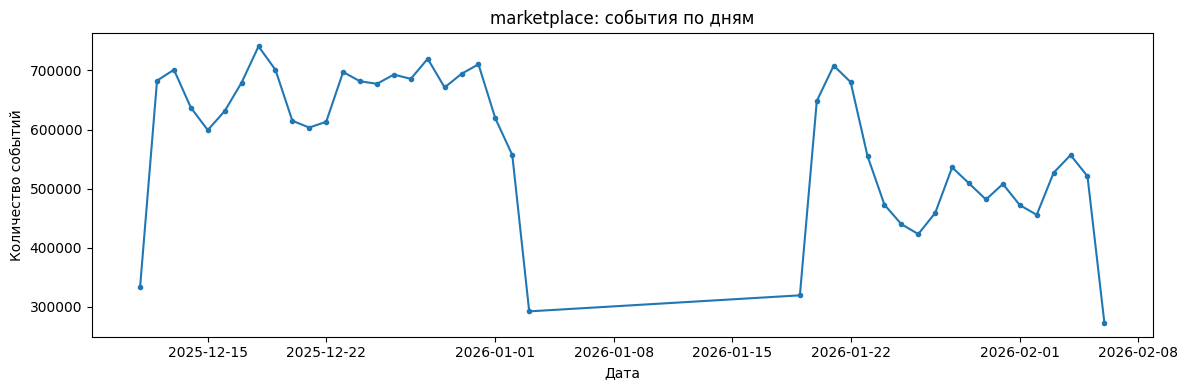

C:\Users\Admin\AppData\Local\Temp\ipykernel_11376\1268001388.py:37: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  hourly_counts = events_df.group_by('hour').agg(pl.count().alias('count')).sort('hour')


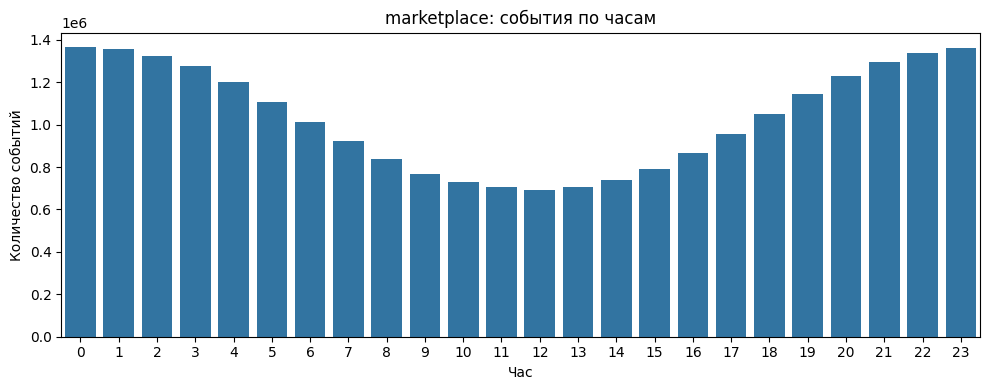

C:\Users\Admin\AppData\Local\Temp\ipykernel_11376\1268001388.py:48: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  dow_counts = events_df.group_by('weekday').agg(pl.count().alias('count')).sort('weekday')


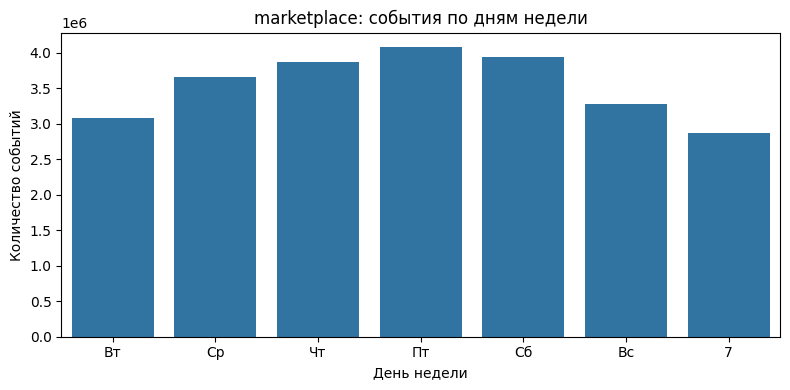

C:\Users\Admin\AppData\Local\Temp\ipykernel_11376\1268001388.py:27: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  daily_counts = events_df.group_by('date').agg(pl.count().alias('count')).sort('date')


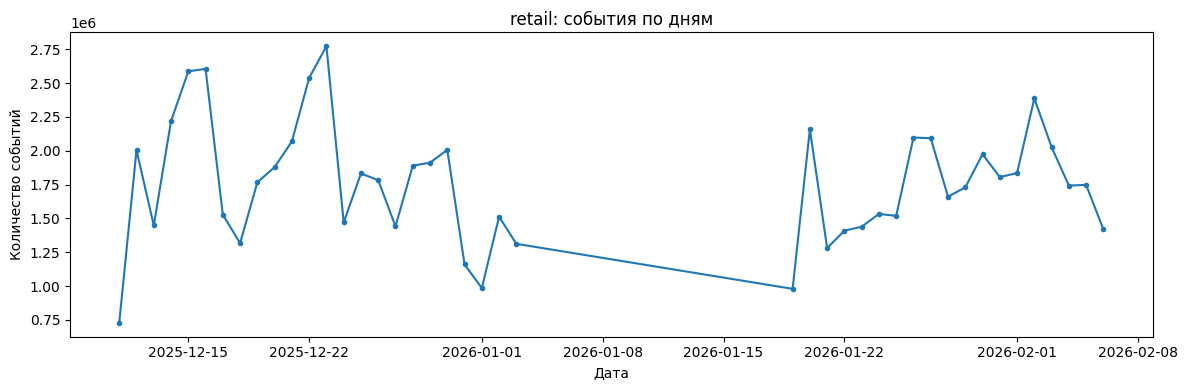

C:\Users\Admin\AppData\Local\Temp\ipykernel_11376\1268001388.py:37: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  hourly_counts = events_df.group_by('hour').agg(pl.count().alias('count')).sort('hour')


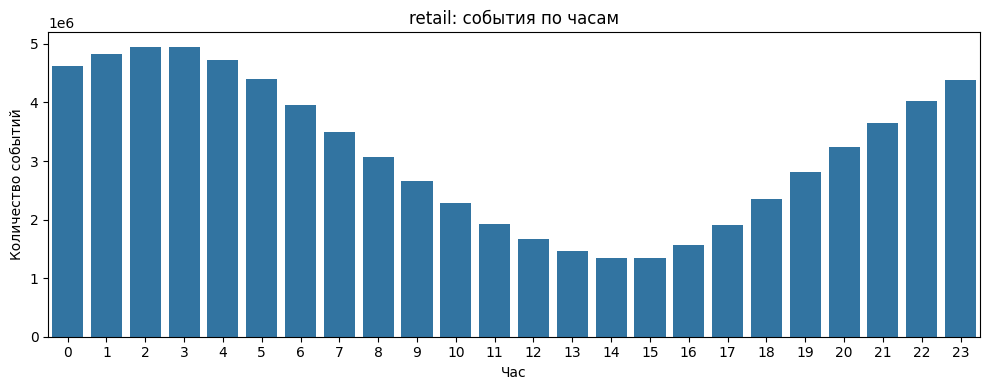

C:\Users\Admin\AppData\Local\Temp\ipykernel_11376\1268001388.py:48: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  dow_counts = events_df.group_by('weekday').agg(pl.count().alias('count')).sort('weekday')


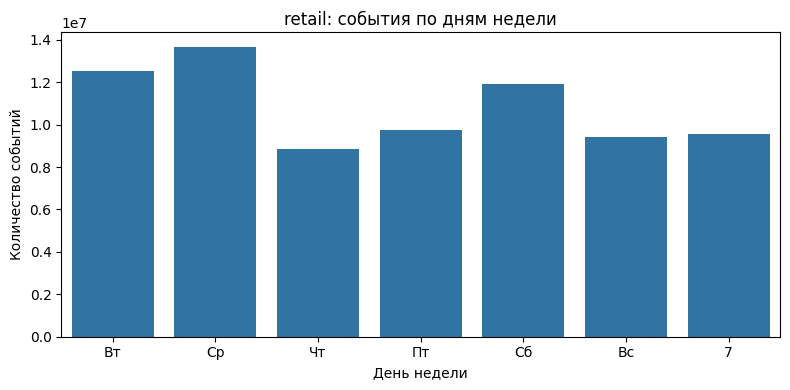

C:\Users\Admin\AppData\Local\Temp\ipykernel_11376\1268001388.py:27: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  daily_counts = events_df.group_by('date').agg(pl.count().alias('count')).sort('date')


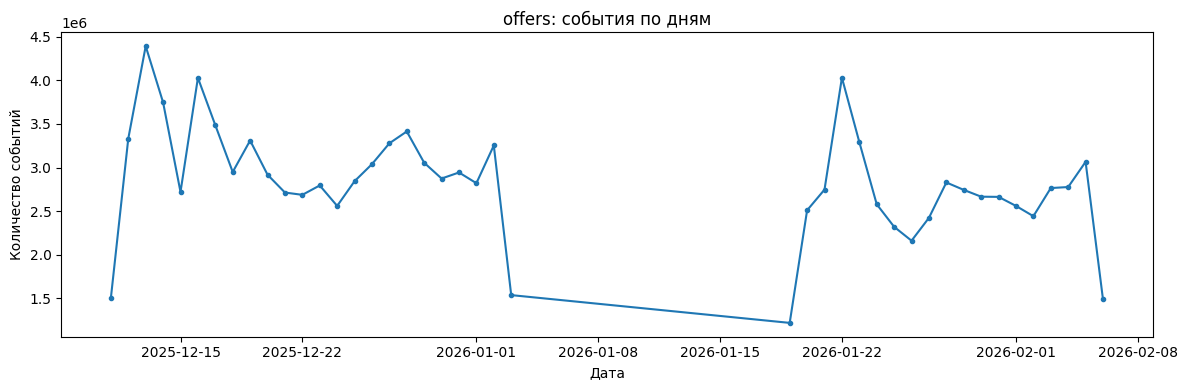

C:\Users\Admin\AppData\Local\Temp\ipykernel_11376\1268001388.py:37: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  hourly_counts = events_df.group_by('hour').agg(pl.count().alias('count')).sort('hour')


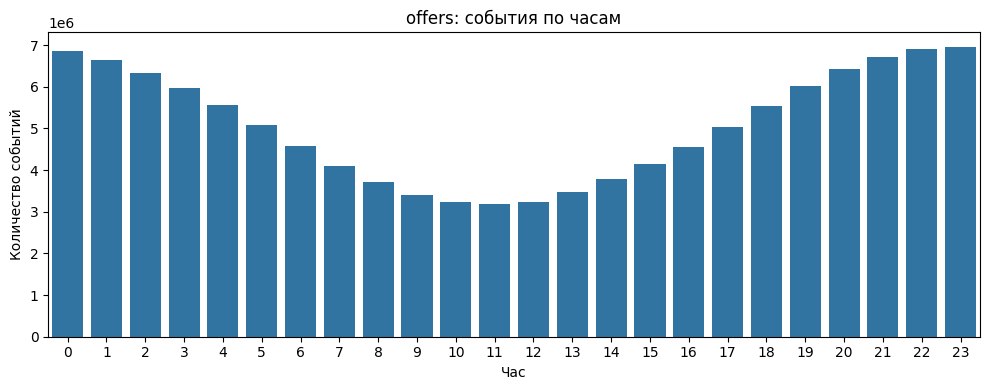

C:\Users\Admin\AppData\Local\Temp\ipykernel_11376\1268001388.py:48: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  dow_counts = events_df.group_by('weekday').agg(pl.count().alias('count')).sort('weekday')


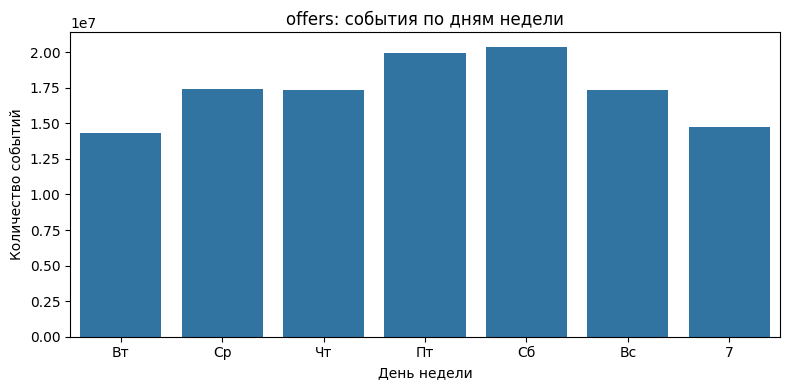

⚠️ Нет записей для домена reviews

👤 3.2. Анализ пользователей и поведения


C:\Users\Admin\AppData\Local\Temp\ipykernel_11376\1281073214.py:26: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  user_activity = events_df.group_by('user_id').agg(pl.count().alias('event_count'))


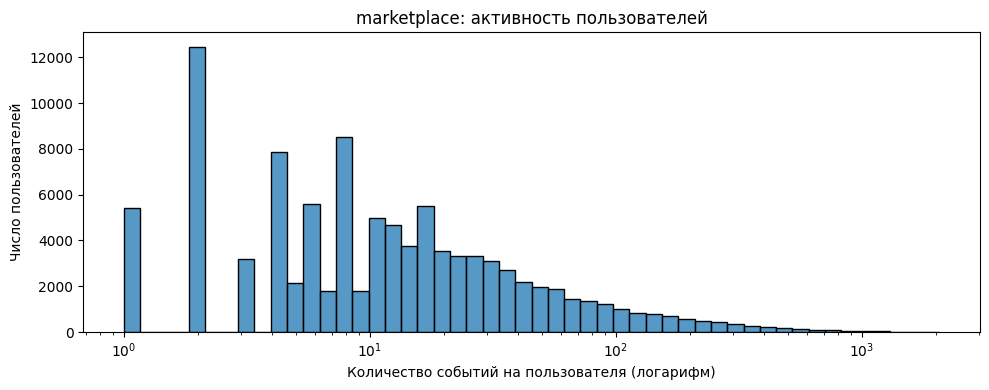

C:\Users\Admin\AppData\Local\Temp\ipykernel_11376\1281073214.py:38: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  action_counts = events_df.group_by('action_type').agg(pl.count().alias('count')).sort('count', descending=True)


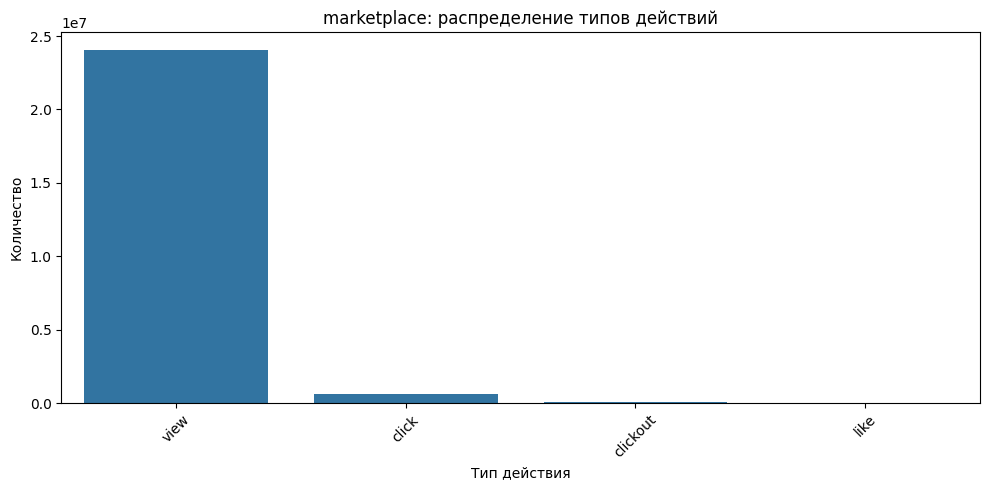

C:\Users\Admin\AppData\Local\Temp\ipykernel_11376\1281073214.py:48: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  os_counts = events_df.group_by('os').agg(pl.count().alias('count')).sort('count', descending=True)


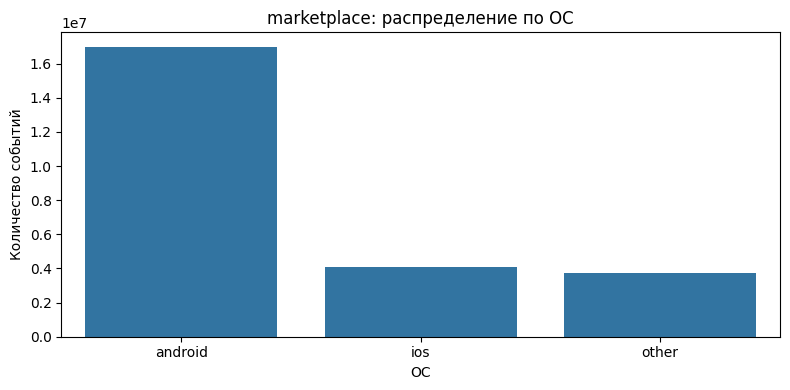

C:\Users\Admin\AppData\Local\Temp\ipykernel_11376\1281073214.py:26: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  user_activity = events_df.group_by('user_id').agg(pl.count().alias('event_count'))


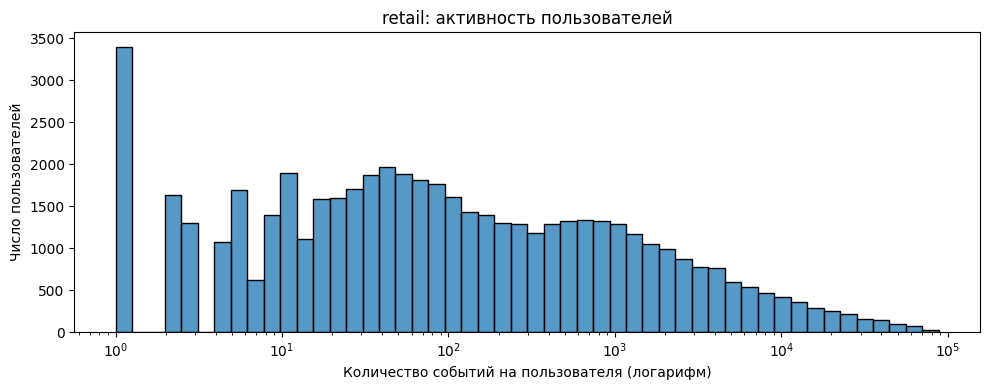

C:\Users\Admin\AppData\Local\Temp\ipykernel_11376\1281073214.py:38: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  action_counts = events_df.group_by('action_type').agg(pl.count().alias('count')).sort('count', descending=True)


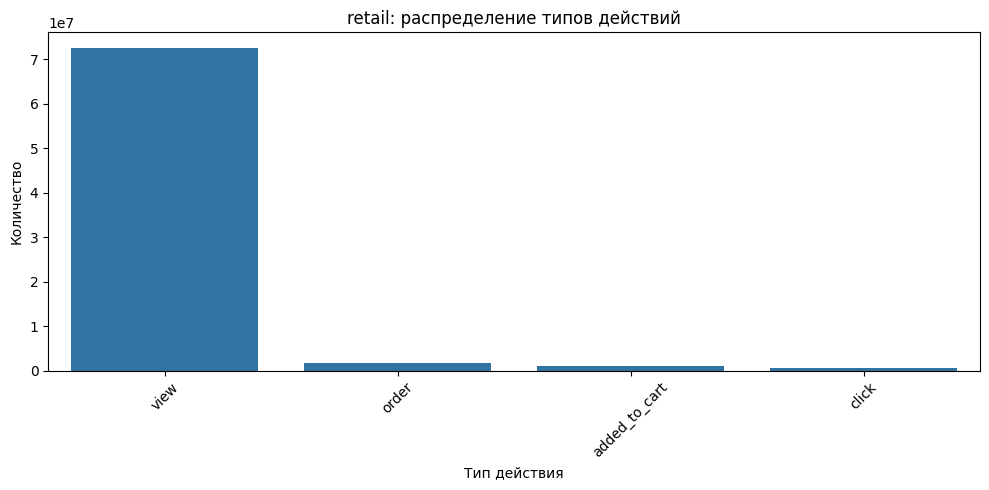

C:\Users\Admin\AppData\Local\Temp\ipykernel_11376\1281073214.py:48: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  os_counts = events_df.group_by('os').agg(pl.count().alias('count')).sort('count', descending=True)


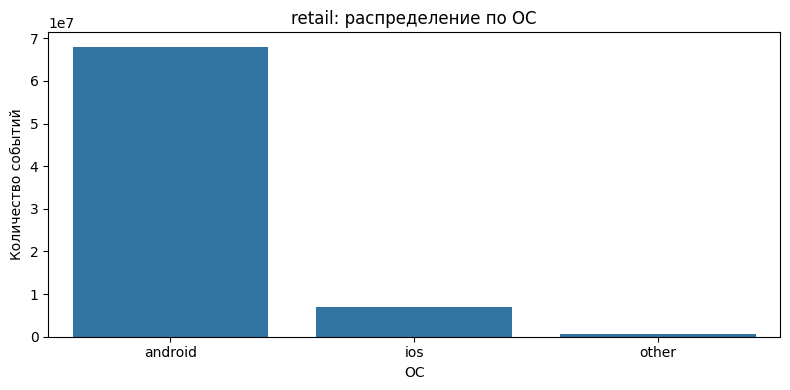

C:\Users\Admin\AppData\Local\Temp\ipykernel_11376\1281073214.py:26: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  user_activity = events_df.group_by('user_id').agg(pl.count().alias('event_count'))


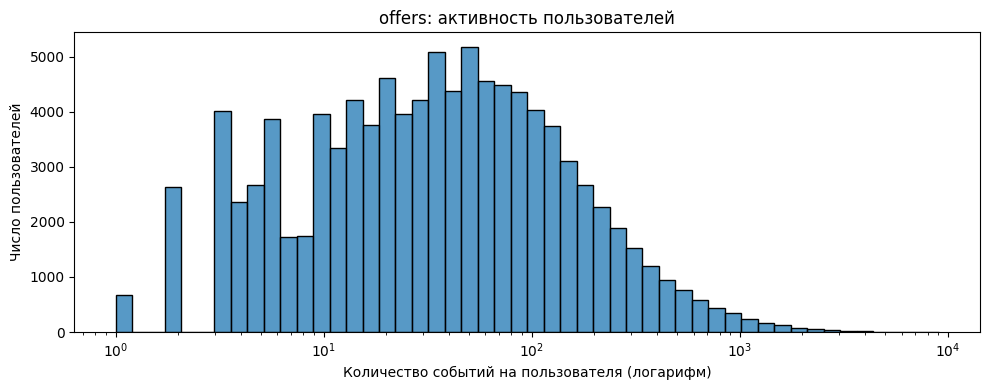

C:\Users\Admin\AppData\Local\Temp\ipykernel_11376\1281073214.py:38: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  action_counts = events_df.group_by('action_type').agg(pl.count().alias('count')).sort('count', descending=True)


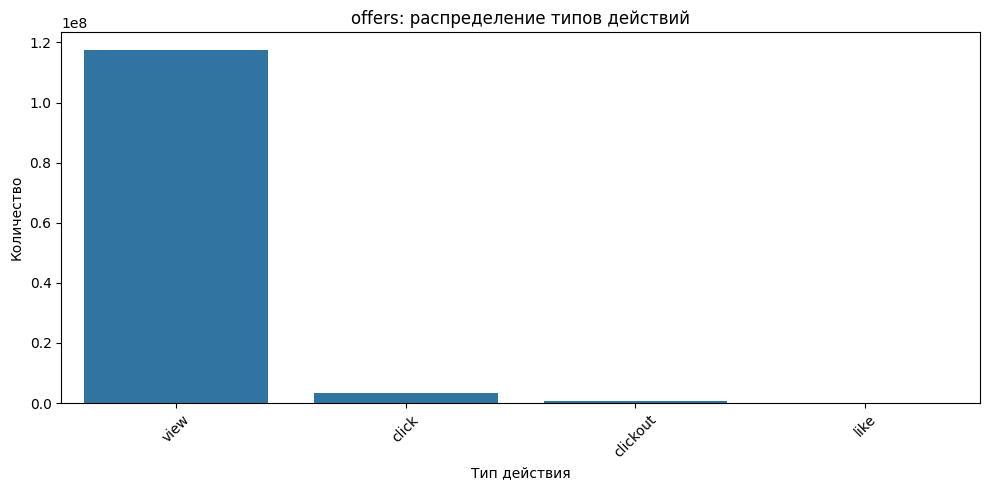

⚠️ Нет записей для домена reviews

🏷️ 3.3. Анализ каталогов (Items & Brands)


C:\Users\Admin\AppData\Local\Temp\ipykernel_11376\3282424630.py:27: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  cat_counts = items_df.group_by(cat_col).agg(pl.count().alias('count')).sort('count', descending=True).head(20)


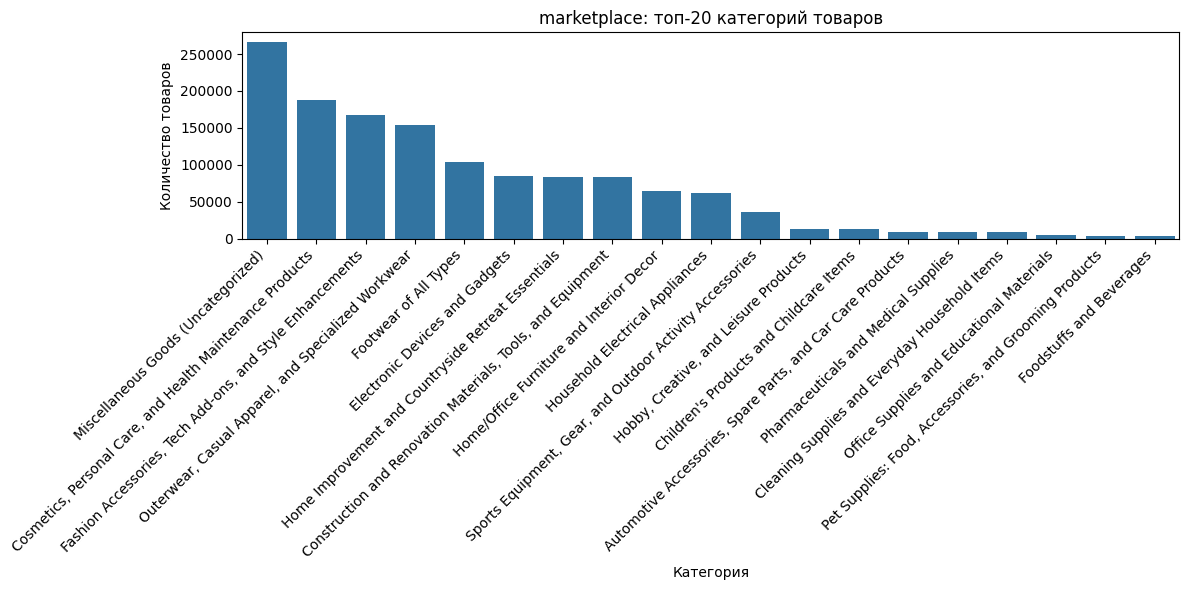

C:\Users\Admin\AppData\Local\Temp\ipykernel_11376\3282424630.py:39: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  brand_counts = items_df.group_by('brand_id').agg(pl.count().alias('count')).sort('count', descending=True).head(20)


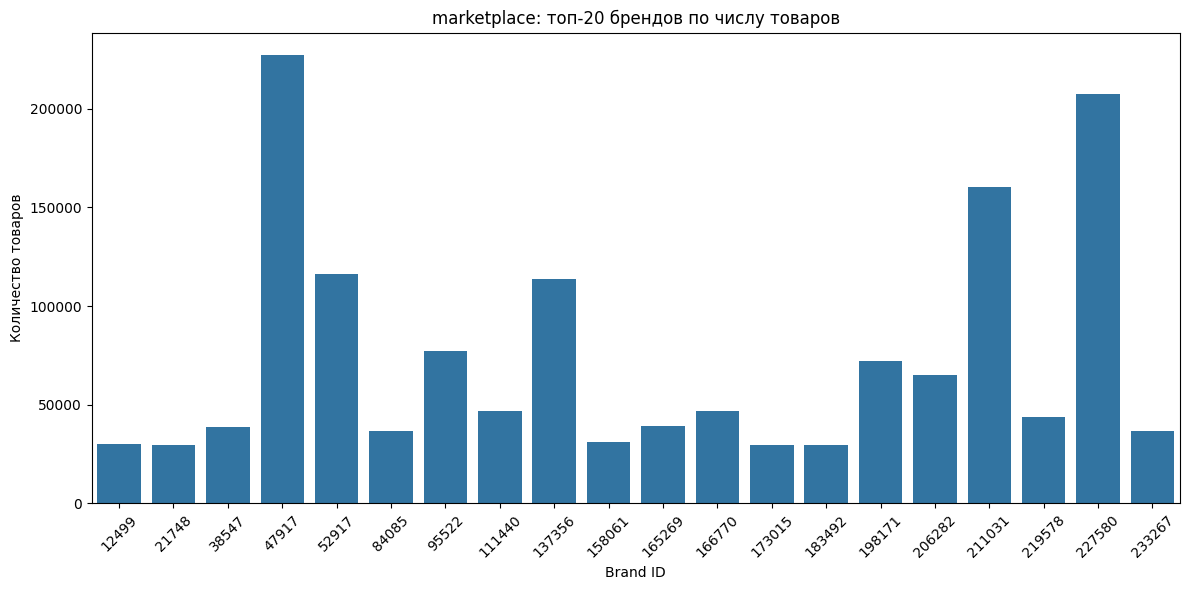

   📐 В marketplace найдены эмбеддинги: ['embedding']
      - embedding: тип <class 'polars.series.series.Series'> (не массив)


C:\Users\Admin\AppData\Local\Temp\ipykernel_11376\3282424630.py:27: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  cat_counts = items_df.group_by(cat_col).agg(pl.count().alias('count')).sort('count', descending=True).head(20)


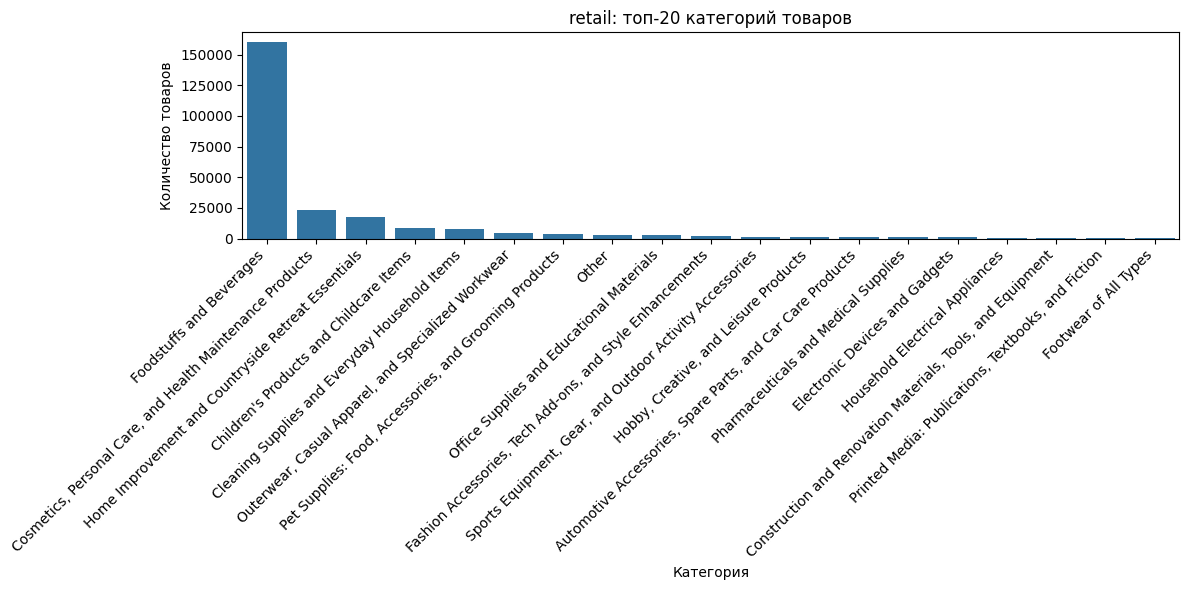

C:\Users\Admin\AppData\Local\Temp\ipykernel_11376\3282424630.py:39: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  brand_counts = items_df.group_by('brand_id').agg(pl.count().alias('count')).sort('count', descending=True).head(20)


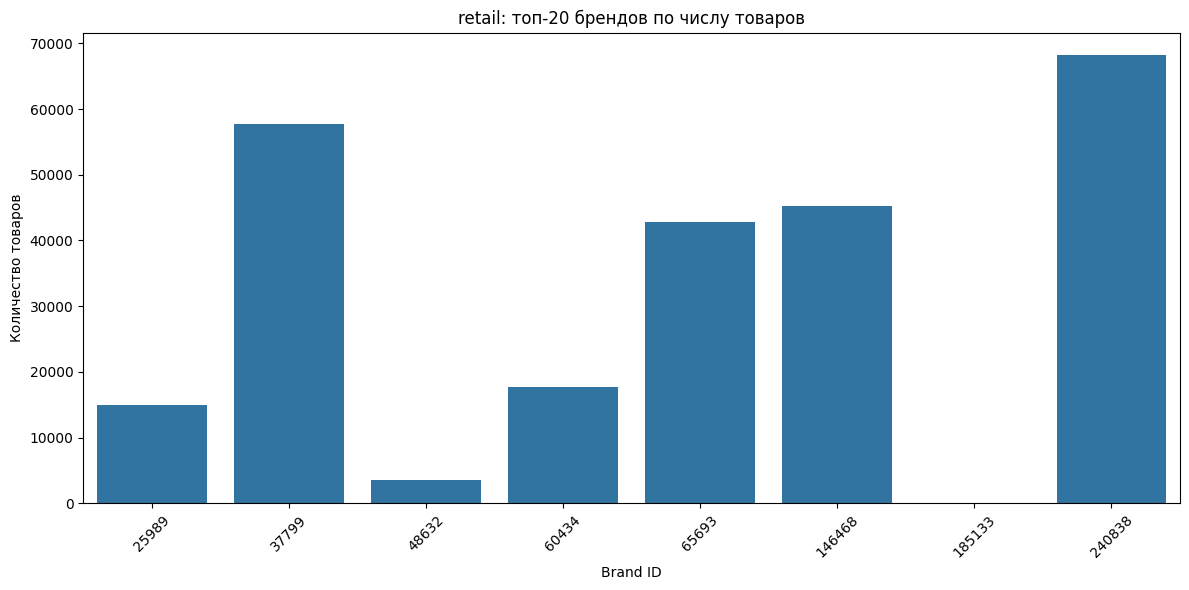

C:\Users\Admin\AppData\Local\Temp\ipykernel_11376\3282424630.py:39: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  brand_counts = items_df.group_by('brand_id').agg(pl.count().alias('count')).sort('count', descending=True).head(20)


   📐 В retail найдены эмбеддинги: ['embedding']
      - embedding: тип <class 'polars.series.series.Series'> (не массив)
ℹ️ Категории не обнаружены в offers


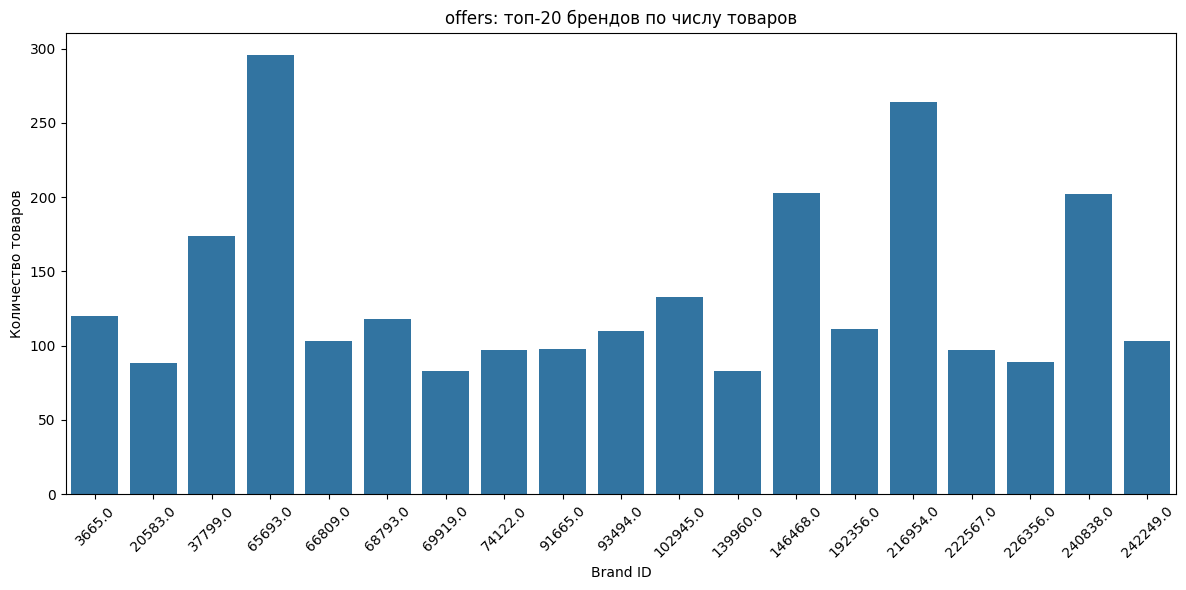

   📐 В offers найдены эмбеддинги: ['embedding']
      - embedding: тип <class 'polars.series.series.Series'> (не массив)
⚠️ Нет записей для домена reviews

💰 3.4. Анализ цен
ℹ️ В marketplace нет колонки price
ℹ️ В retail нет колонки price
ℹ️ В offers нет колонки price
ℹ️ В reviews нет записей

🔗 3.5. Кросс-доменный анализ
Нет записей для домента  reviews

• Пересечения пользователей между доменами:
   marketplace ∩ retail: 41,531 общих пользователей
   marketplace ∩ offers: 590,088 общих пользователей
   retail ∩ offers: 50,122 общих пользователей


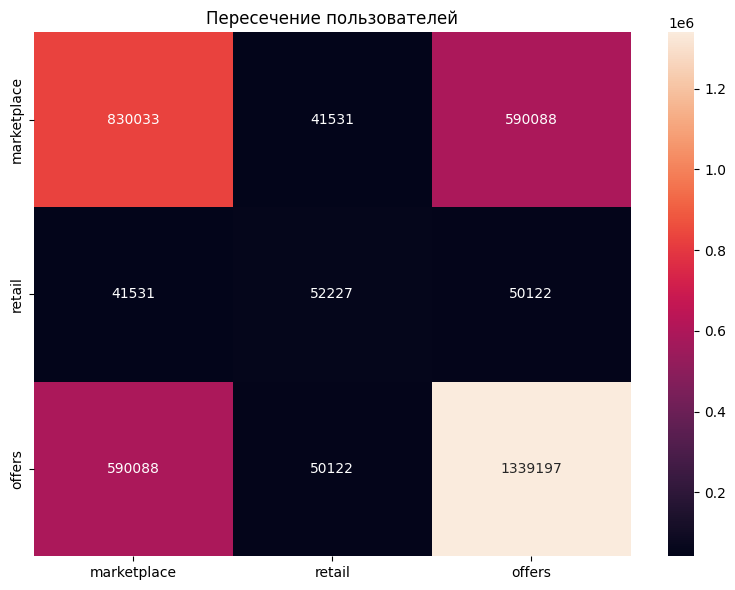

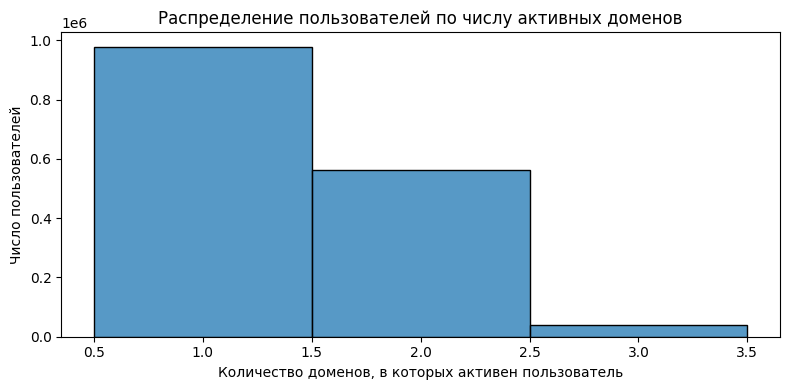

C:\Users\Admin\AppData\Local\Temp\ipykernel_11376\250122987.py:77: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  grouped = events_df.group_by('user_id').agg(pl.count().alias('cnt'))


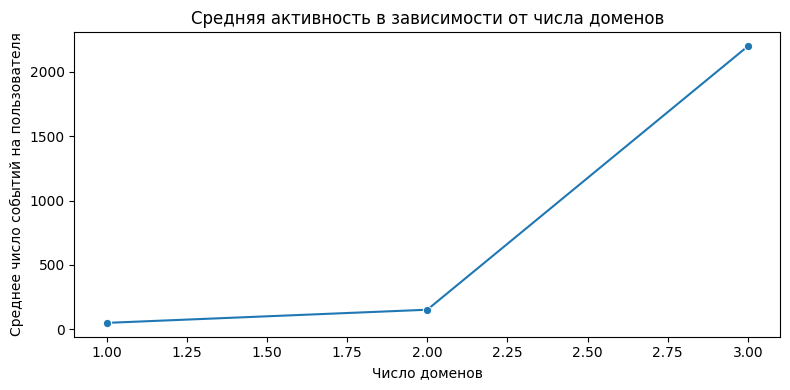


⭐ 3.6. Анализ отзывов (reviews)
ℹ️ Домен reviews отсутствует


In [77]:
data_dict = collect_events(data)
# Выполняем анализ по разделам
temporal_analysis(data)
user_behavior_analysis(data)
catalog_analysis(data)
price_analysis(data)
cross_domain_analysis(data)
reviews_analysis(data)

---

## 📌 Разбор графиков раздела 3

### ⏰ 3.1. Временной анализ

**События по дням** (`marketplace_daily.png`, `retail_daily.png`, `offers_daily.png`)

* На всех трёх доменах виден **разрыв во временном покрытии**: примерно с начала января до ~20-го января
  точек нет — линия просто соединяет два края. Это **пропущенные суточные партии** в скачанном срезе,
  а не падение трафика. Первый и последний дни также заметно ниже соседних — это **неполные сутки**
  (обрезанные края окна).
* **Уровни трафика:** `offers` ≈ 2.5–4.4 млн событий/день, `retail` ≈ 1.0–2.8 млн, `marketplace` ≈ 0.3–0.75 млн.
* **Виден структурный сдвиг:** в декабрьской части `marketplace` держится на уровне ~0.65–0.74 млн/день,
  а после разрыва — на ~0.45–0.55 млн/день. То есть распределение до и после «дырки» **не стационарно**.

> **Следствие для моделирования:** нельзя делать случайное разбиение train/test. Нужен строго
> **временной сплит**, при этом валидацию следует брать из «поздней» части, а первый/последний
> неполные дни исключать. Разрыв в данных надо явно учитывать при построении признаков recency —
> иначе «давность последнего действия» будет искажена на 2.5 недели.

**События по часам** (`*_hourly.png`)

Профиль **одинаков во всех доменах и явно перевёрнут**: максимум приходится на 0–4 часа,
минимум — на 10–15 часов. Реальное потребительское поведение выглядит наоборот (пик вечером).
Причина — синтетическая база отсчёта времени в `ensure_timestamp` (`datetime(2022,7,10,12,00)`):
получившиеся «часы» сдвинуты относительно локального времени пользователя примерно на 12 часов.

> **Вывод:** форма кривой (амплитуда суточных колебаний ~2× для marketplace/offers и ~3.7× для retail)
> достоверна, а вот **привязка к конкретному часу — нет**. Признак `hour` можно использовать как
> циклический (sin/cos), но интерпретировать «пик в полночь» как реальное поведение нельзя.
> Перед продакшеном базу отсчёта нужно откалибровать по документации датасета.

**События по дням недели** (`*_weekday.png`)

Разброс между днями небольшой (для marketplace 2.9–4.1 млн, т.е. ±15% вокруг среднего): максимум — «Пт»,
минимум — последняя категория. Обратите внимание на **техническую ошибку в подписи**: в Polars
`dt.weekday()` возвращает 1–7 (Пн=1), а код индексирует список `['Пн',...,'Вс']` с нуля, поэтому
метки сдвинуты на один день и появляется категория «7». Реальный максимум приходится на **четверг**,
а не на пятницу.

> **Вывод:** недельная сезонность слабая, но существует; при этом подписи графика требуют исправления
> (индексация `x-1`). Как признак день недели полезен слабо — приоритет у recency и частоты.

### 👤 3.2. Пользователи и поведение

**Активность на пользователя** (`*_user_activity.png`, лог-шкала)

| Домен | Пользователей | Среднее событий/пользователя | Диапазон на графике |
|---|---:|---:|---|
| `marketplace` | 830 033 | **29.9** | 1 … ~2·10³ |
| `retail` | 52 227 | **1 447.9** | 1 … ~10⁵ |
| `offers` | 1 339 197 | **90.7** | 1 … ~10⁴ |

Все три распределения — **тяжелохвостые, близкие к лог-нормальным**, вытянутые на 3–5 порядков.
В `marketplace` доминируют «одноразовые» пользователи (пик на 1–2 событиях, ~18 тыс. из 100-тысячной выборки),
в `retail` — наоборот, заметная масса «супер-активных» покупателей с 10³–10⁵ событий,
в `offers` мода приходится на 30–60 показов.

> **Следствие:** `retail` — это не столько «много пользователей», сколько **очень плотная история
> у немногих** (52 тыс. человек генерируют 75.6 млн событий). Для ALS это означает необходимость
> **нормировать confidence** (например, `log1p` или BM25-взвешивание), иначе десяток тяжёлых
> пользователей перетянет на себя факторизацию. Одновременно длинный левый край (1–2 события)
> — это **cold-start сегмент**, который матричная факторизация обслужить не сможет; для него нужен
> популярностный/контентный fallback.

**Типы действий** (`*_action_types.png`)

Распределение экстремально несбалансированное — по срезу из `eda_reference.json`:

| Действие | marketplace | offers | Доля (marketplace) |
|---|---:|---:|---:|
| `view` | 652 666 | 1 284 069 | **97.0%** |
| `click` | 17 453 | 35 626 | 2.6% |
| `clickout` | 2 222 | 7 007 | 0.33% |
| `like` | 194 | 763 | **0.03%** |

Итого «сильные» сигналы (`clickout`, `like`) составляют доли процента. На графиках видны только
столбцы `view`, остальные визуально сливаются с нулём.

> **Следствие:** сигналы неявные и сильно зашумлённые. Разумная стратегия — **взвешенный implicit-feedback**:
> задать разные веса confidence для `view` / `click` / `clickout` / `like` (например, 1 / 5 / 20 / 30),
> а метрики качества считать по редким конверсионным событиям, а не по просмотрам. Обучать на `view`
> и валидировать на `view` — значит оптимизировать показы, а не бизнес-результат.

**Операционные системы** (`marketplace_os.png`, `retail_os.png`)

| Домен | android | ios | other |
|---|---:|---:|---:|
| `marketplace` | ~16.9 млн (68%) | ~4.0 млн (16%) | ~3.7 млн (15%) |
| `retail` | ~67.9 млн (90%) | ~7.0 млн (9%) | ~0.5 млн (<1%) |

Android доминирует везде, но в `retail` доля веб/прочего практически нулевая — это **мобильное
приложение**, тогда как в `marketplace` заметен веб-канал. В `offers` колонка `os` вообще отсутствует.

> **Следствие:** `os` — полезный, но **не универсальный** признак: он есть только в двух доменах из трёх.
> В объединённой витрине он даёт ~66% пропусков, поэтому в общей модели его следует кодировать
> с отдельной категорией `unknown` или использовать только в домен-специфичных моделях.

### 🏷️ 3.3. Каталог: категории и бренды

**Категории** (`marketplace_categories.png`, `retail_categories.png`)

* В `marketplace` крупнейшая «категория» — **Miscellaneous Goods (Uncategorized)** (~265 тыс. товаров),
  то есть самый частый класс — это фактически отсутствие разметки. Далее идут косметика (~187 тыс.),
  fashion-аксессуары (~166 тыс.) и одежда (~152 тыс.). Всего 23 категории / 193 подкатегории.
* В `retail` распределение **крайне сконцентрировано**: `Foodstuffs and Beverages` ≈ 160 тыс. товаров
  из 250 тыс. (≈64%), остальные категории — менее 25 тыс. каждая. 21 категория / 175 подкатегорий.
* В `offers` категорий нет вовсе — только `item_id`, `brand_id` и эмбеддинг.

> **Следствие:** таксономия не является надёжным общим признаком. В `marketplace` она наполовину пуста,
> в `retail` вырождена в одну доминирующую категорию, в `offers` отсутствует. Для контентной части
> лучше опираться на **товарные эмбеддинги** (300/312 dim, заполнены почти полностью), а категорию
> использовать как вспомогательный признак с явным `unknown`.

**Бренды** (`marketplace_brands.png`, `retail_brands.png`, `offers_brands.png`)

Топ-20 брендов маркетплейса заметно неоднородны: лидер (`47917`) ~227 тыс. товаров, второй (`227580`)
~207 тыс., третий (`211031`) ~160 тыс., а «хвост» топ-20 — по 29–47 тыс. Учитывая, что весь каталог
2.33 млн товаров, **три бренда дают ~25% ассортимента** — вероятно, это агрегаторы/маркетплейс-продавцы,
а не бренды в маркетинговом смысле.

> **Следствие:** `brand_id` как категориальный признак имеет крайне неравномерное распределение
> (нужен target/frequency encoding, а не one-hot по 29 485 значениям), а эмбеддинги брендов
> использовать почти нельзя из-за 76% пропусков.

### 💰 3.4. Цены

Анализ не выполнен: колонка `price` присутствует только в `items`, но **не в событиях**, а функция
`price_analysis` ищет её именно в `events_df`. Соответствующая часть корректно вывела «нет колонки price».

> **Что стоит доработать:** присоединить `price` из `items` к событиям по `item_id` — тогда появятся
> ценовые признаки уровня взаимодействия (средний чек интереса пользователя, ценовой сегмент товара,
> отклонение цены товара от медианы его категории). Это один из самых дешёвых способов усилить
> модель второго уровня.

### 🔗 3.5. Кросс-доменный анализ

**Матрица пересечений** (`cross_user_overlap.png`) — на диагонали размер аудитории домена,
вне диагонали — общие пользователи:

| | marketplace | retail | offers |
|---|---:|---:|---:|
| **marketplace** | **830 033** | 41 531 | 590 088 |
| **retail** | 41 531 | **52 227** | 50 122 |
| **offers** | 590 088 | 50 122 | **1 339 197** |

Ключевые наблюдения:

* **`marketplace` ∩ `offers` = 590 088** — это 71% аудитории маркетплейса и 44% аудитории офферов.
  Пара доменов практически «сросшаяся»: офферы показываются тем же людям.
* **`retail` почти целиком вложен в остальные домены:** из 52 227 его пользователей 41 531 (80%)
  есть в `marketplace` и 50 122 (96%) — в `offers`. Автономных ритейл-пользователей почти нет.
* **Асимметрия огромна:** `offers` в 25 раз больше `retail` по аудитории.

**Число доменов на пользователя** (`user_domain_count.png`)

| Активен в … | Пользователей | Доля |
|---|---:|---:|
| 1 домене | ~978 тыс. | 61.9% |
| 2 доменах | ~561 тыс. | 35.5% |
| 3 доменах | ~40 тыс. | 2.5% |

Всего 1 579 878 уникальных пользователей, из них **601 417 (38.1%) — мультидоменные**.

**Активность vs число доменов** (`activity_vs_domains.png`)

Зависимость резко **выпуклая (супер-линейная)**: ~45 событий в среднем у однодоменных, ~150 у двухдоменных
и **~2 200 у трёхдоменных** — то есть почти в 50 раз больше, чем у однодоменных.

> **Главный вывод раздела:** кросс-доменность — не просто «пересечение множеств», а **сильный
> предиктор вовлечённости**. Число активных доменов и признаки активности в соседнем домене
> обязаны попасть в модель второго уровня. При этом надо помнить о **направлении причинности**:
> связь может объясняться тем, что активные пользователи в принципе чаще встречаются везде
> (эффект экспозиции), — использовать признак как предиктор можно, как обоснование продуктовых
> решений («втянем пользователя в третий домен → он станет активнее») — нет, для этого нужен эксперимент.
>
> Практически: 38% общей аудитории — реальная база для кросс-доменного переноса, а 62% однодоменных
> пользователей задают потолок того, что такой перенос вообще может дать.

### ⭐ 3.6. Отзывы

Домен `reviews` в срезе `small` отсутствует, анализ рейтингов не выполнялся.

# 📈 4. Интерпретация

In [90]:
def print_interpretations(data_dict):
    """
    Выводит текстовые интерпретации по каждому аспекту EDA.
    Использует ранее вычисленные статистики (или вычисляет их заново).
    """
    print("\n" + "="*60)
    print("📝 ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ")
    print("="*60)
    
    domains = data_dict.get('domains', {})
    
    # 1. Общие метрики
    print("\n• Общая статистика по датасету:")
    total_events = 0
    total_users = set()
    for dom_name, dom_data in domains.items():
        if dom_data:
            events_df = dom_data.get('events_df')
        else:
            print(f"⚠️ Нет записей для домена {dom_name}")
            events_df = None
        if events_df is not None and not events_df.is_empty():
            total_events += events_df.height
            if 'user_id' in events_df.columns:
                total_users.update(events_df['user_id'].unique().to_list())
    print(f"   - Всего событий во всех доменах: {total_events:,}")
    print(f"   - Уникальных пользователей (по всем доменам): {len(total_users):,}")
    
    # 2. Временные паттерны
    print("\n• Временные паттерны:")
    for dom_name, dom_data in domains.items():
        if dom_data:
            events_df = dom_data.get('events_df')
        else:
            print(f"⚠️ Нет записей для домена {dom_name}")
            events_df = None
        if events_df is None or events_df.is_empty():
            continue
        if 'datetime' in events_df.columns:
            # пиковый час
            hour_counts = events_df.group_by('hour').agg(pl.count().alias('cnt')).sort('cnt', descending=True)
            if not hour_counts.is_empty():
                peak_hour = hour_counts.row(0)[0]
                print(f"   - {dom_name}: пик активности в {peak_hour}:00")
            # день недели с максимумом
            if 'weekday' in events_df.columns:
                dow_counts = events_df.group_by('weekday').agg(pl.count().alias('cnt')).sort('cnt', descending=True)
                if not dow_counts.is_empty():
                    peak_dow = dow_counts.row(0)[0]
                    dow_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
                    print(f"   - {dom_name}: самый активный день – {dow_names[peak_dow]}")
    
    # 3. Поведение пользователей
    print("\n• Поведение пользователей:")
    for dom_name, dom_data in domains.items():
        if dom_data:
            events_df = dom_data.get('events_df')
        else:
            print(f"⚠️ Нет записей для домена {dom_name}")
            events_df = None
        if events_df is None or events_df.is_empty():
            continue
        if 'user_id' in events_df.columns and 'action_type' in events_df.columns:
            # среднее число событий на пользователя
            avg_events_per_user = events_df.group_by('user_id').agg(pl.count().alias('cnt')).get_column('cnt').mean()
            print(f"   - {dom_name}: в среднем {avg_events_per_user:.2f} событий на пользователя")
            # топ-действие
            top_action = events_df.group_by('action_type').agg(pl.count().alias('cnt')).sort('cnt', descending=True).row(0)[0]
            print(f"   - {dom_name}: самое частое действие – '{top_action}'")
    
    # 4. Цены
    print("\n• Ценовые характеристики:")
    all_prices = []
    for dom_name, dom_data in domains.items():
        if dom_data:
            events_df = dom_data.get('events_df')
        else:
            print(f"⚠️ Нет записей для домена {dom_name}")
            events_df = None
        if events_df is not None and 'price' in events_df.columns:
            prices = events_df['price'].drop_nulls()
            if not prices.is_empty():
                median_price = prices.median()
                mean_price = prices.mean()
                print(f"   - {dom_name}: медианная цена = {median_price:.2f}, средняя = {mean_price:.2f}")
                all_prices.extend(prices.to_list())
    if all_prices:
        overall_median = np.median(all_prices)
        overall_mean = np.mean(all_prices)
        print(f"   - По всем доменам: медиана = {overall_median:.2f}, средняя = {overall_mean:.2f}")
    
    # 5. Кросс-доменные пересечения
    print("\n• Кросс-доменные связи:")
    user_sets = {}
    for dom_name, dom_data in domains.items():
        if dom_data:
            events_df = dom_data.get('events_df')
        else:
            print(f"⚠️ Нет записей для домена {dom_name}")
            events_df = None
        if events_df is not None and 'user_id' in events_df.columns:
            user_sets[dom_name] = set(events_df['user_id'].unique().to_list())
    dom_names = list(user_sets.keys())
    if len(dom_names) > 1:
        # среднее пересечение
        intersections = []
        for i in range(len(dom_names)):
            for j in range(i+1, len(dom_names)):
                inter = len(user_sets[dom_names[i]] & user_sets[dom_names[j]])
                intersections.append(inter)
        avg_inter = np.mean(intersections) if intersections else 0
        print(f"   - Среднее число общих пользователей между парами доменов: {avg_inter:.0f}")
        # доля пользователей, активных в нескольких доменах
        multi_domain_users = 0
        all_users = set()
        for users in user_sets.values():
            all_users.update(users)
        for u in all_users:
            count = sum(1 for s in user_sets.values() if u in s)
            if count > 1:
                multi_domain_users += 1
        if all_users:
            pct = multi_domain_users / len(all_users) * 100
            print(f"   - {multi_domain_users:,} пользователей ({pct:.1f}%) активны в >1 домене")
    
    # 6. Отзывы (если есть)
    reviews_data = domains.get('reviews')
    if reviews_data is not None:
        items_rev = reviews_data.get('items')
        if items_rev is not None and not items_rev.is_empty():
            rating_cols = [c for c in items_rev.columns if 'rating' in c.lower() or 'score' in c.lower()]
            if rating_cols:
                print("\n• Отзывы:")
                for col in rating_cols:
                    if items_rev[col].dtype in (pl.Int64, pl.Float64):
                        avg_rating = items_rev[col].mean()
                        print(f"   - Средний рейтинг ({col}): {avg_rating:.2f}")

# 🧠 5. Дополнительные проверки (с учётом специфики датасета)

In [87]:
def additional_checks(data_dict):
    """
    Проверки на аномалии, data leakage, анонимизацию и репрезентативность.
    """
    print("\n" + "="*60)
    print("🧠 5. ДОПОЛНИТЕЛЬНЫЕ ПРОВЕРКИ")
    print("="*60)
    
    domains = data_dict.get('domains', {})
    
    # ------------------------------------------------------------
    # 5.1. Проверка аномалий (выбросов) в ценах и количестве
    # ------------------------------------------------------------
    print("\n• Аномалии в числовых признаках:")
    for dom_name, dom_data in domains.items():
        if dom_data:
            events_df = dom_data.get('events_df')
        else:
            print(f"⚠️ Нет записей для домена {dom_name}")
            continue
        if events_df is None or events_df.is_empty():
            continue
        # Цена
        if 'price' in events_df.columns:
            prices = events_df['price'].drop_nulls()
            if not prices.is_empty():
                q99 = prices.quantile(0.99)
                q999 = prices.quantile(0.999)
                max_price = prices.max()
                # количество записей с ценой > q999
                outliers = prices.filter(prices > q999).len()
                print(f"   - {dom_name}: {outliers} записей с ценой > 99.9-го перцентиля ({q999:.2f})")
                if max_price > 1e6:
                    print(f"     ⚠️ Обнаружена экстремально высокая цена: {max_price:.2f}")
        # Количество (если есть колонка 'count' или 'quantity')
        if 'count' in events_df.columns:
            cnt = events_df['count'].drop_nulls()
            if not cnt.is_empty():
                max_cnt = cnt.max()
                if max_cnt > 1000:
                    print(f"   - {dom_name}: максимальное количество (count) = {max_cnt} (возможный выброс)")
    
    # ------------------------------------------------------------
    # 5.2. Проверка data leakage (последние 12 часов)
    # ------------------------------------------------------------
    print("\n• Проверка на data leakage (последние 12 часов):")
    for dom_name, dom_data in domains.items():
        if dom_data:
            events_df = dom_data.get('events_df')
        else:
            print(f"⚠️ Нет записей для домена {dom_name}")
            continue
        if events_df is None or events_df.is_empty():
            continue
        if 'datetime' in events_df.columns:
            max_time = events_df['datetime'].max()
            min_time = events_df['datetime'].min()
            # определяем последние 12 часов относительно максимума
            cutoff = max_time - timedelta(hours=12)
            last_12h_count = events_df.filter(pl.col('datetime') >= cutoff).height
            total = events_df.height
            pct = last_12h_count / total * 100 if total > 0 else 0
            print(f"   - {dom_name}: {last_12h_count:,} событий ({pct:.2f}%) попадают в последние 12 часов.")
            if pct > 0:
                print(f"     ⚠️ Эти данные не должны использоваться для обучения (как указано в документации).")
    
    # ------------------------------------------------------------
    # 5.3. Проверка анонимизации (редкие комбинации)
    # ------------------------------------------------------------
    print("\n• Проверка анонимизации (уникальность идентификаторов):")
    for dom_name, dom_data in domains.items():
        if dom_data:
            events_df = dom_data.get('events_df')
        else:
            print(f"⚠️ Нет записей для домена {dom_name}")
            continue
        if events_df is not None:
            if 'user_id' in events_df.columns:
                n_users = events_df['user_id'].n_unique()
                n_events = events_df.height
                # если каждый пользователь встречается в среднем 1 раз, то возможно переанонимизация
                avg = n_events / n_users if n_users > 0 else 0
                print(f"   - {dom_name}: {n_users:,} уникальных пользователей, в среднем {avg:.2f} событий на пользователя.")
                if avg < 1.1:
                    print(f"     ⚠️ Очень низкая средняя активность – возможно, данные сильно разрежены.")
            if 'brand_id' in events_df.columns:
                n_brands = events_df['brand_id'].n_unique()
                print(f"   - {dom_name}: {n_brands:,} уникальных брендов.")
        # Также проверим items
        items_df = dom_data.get('items')
        if items_df is not None:
            if 'item_id' in items_df.columns:
                n_items = items_df['item_id'].n_unique()
                print(f"   - {dom_name} (items): {n_items:,} уникальных товаров.")
    
    # ------------------------------------------------------------
    # 5.4. Репрезентативность (сравнение с описанием датасета)
    # ------------------------------------------------------------
    print("\n• Репрезентативность относительно описания T-ECD:")
    # Из описания: T-ECD Small содержит ~2.3M событий (для всех доменов), ~100k пользователей?
    # Точные цифры не указаны, но мы можем дать сравнение с тем, что ожидается.
    # Просто выведем наши метрики и предложим пользователю сравнить с документацией.
    total_events = 0
    total_users = set()
    domains_present = []
    for dom_name, dom_data in domains.items():
        if dom_data:
            events_df = dom_data.get('events_df')
        else:
            print(f"⚠️ Нет записей для домена {dom_name}")
            continue
        if events_df is not None and not events_df.is_empty():
            total_events += events_df.height
            if 'user_id' in events_df.columns:
                total_users.update(events_df['user_id'].unique().to_list())
            domains_present.append(dom_name)
    print(f"   - Загружено доменов: {', '.join(domains_present)}")
    print(f"   - Всего событий: {total_events:,}")
    print(f"   - Всего уникальных пользователей: {len(total_users):,}")
    print("   (Сравните с официальными цифрами для T-ECD Small, чтобы оценить репрезентативность.)")

In [91]:
# 4. Интерпретация результатов
print_interpretations(data)


📝 ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ

• Общая статистика по датасету:
⚠️ Нет записей для домена reviews
   - Всего событий во всех доменах: 221,890,993
   - Уникальных пользователей (по всем доменам): 1,579,878

• Временные паттерны:
⚠️ Нет записей для домена reviews

• Поведение пользователей:


C:\Users\Admin\AppData\Local\Temp\ipykernel_11376\4215604369.py:65: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  avg_events_per_user = events_df.group_by('user_id').agg(pl.count().alias('cnt')).get_column('cnt').mean()


   - marketplace: в среднем 29.86 событий на пользователя
   - marketplace: самое частое действие – 'view'


C:\Users\Admin\AppData\Local\Temp\ipykernel_11376\4215604369.py:68: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  top_action = events_df.group_by('action_type').agg(pl.count().alias('cnt')).sort('cnt', descending=True).row(0)[0]


   - retail: в среднем 1447.90 событий на пользователя
   - retail: самое частое действие – 'view'
   - offers: в среднем 90.72 событий на пользователя
   - offers: самое частое действие – 'view'
⚠️ Нет записей для домена reviews

• Ценовые характеристики:
⚠️ Нет записей для домена reviews

• Кросс-доменные связи:
⚠️ Нет записей для домена reviews
   - Среднее число общих пользователей между парами доменов: 227247
   - 601,417 пользователей (38.1%) активны в >1 домене


### 📌 Что показала сводная интерпретация

| Метрика | Значение |
|---|---:|
| Всего событий (3 домена) | **221 890 993** |
| Уникальных пользователей | **1 579 878** |
| Пользователей более чем в одном домене | 601 417 (**38.1%**) |
| Среднее число общих пользователей на пару доменов | 227 247 |
| Средняя активность: marketplace | 29.86 события/пользователя |
| Средняя активность: retail | **1 447.90** события/пользователя |
| Средняя активность: offers | 90.72 события/пользователя |
| Самое частое действие во всех доменах | `view` |

**Наблюдения:**

1. **Разброс средней активности между доменами — почти в 50 раз.** Обучать одну модель на объединённой
   витрине без нормировки нельзя: `retail` подавит остальные домены просто объёмом строк.
2. **Блок «Временные паттерны» ничего не вывел** — потому что колонки `datetime`/`hour` создаются внутри
   `temporal_analysis` в локальной копии DataFrame и не сохраняются в `data`. Это дефект кода, а не данных:
   пиковые часы, которые видны на графиках выше, до сводки просто не дошли.
3. **Ценовой блок пуст** по уже описанной причине — `price` живёт в `items`, а не в событиях.

In [89]:
    # 5. Дополнительные проверки
additional_checks(data)


🧠 5. ДОПОЛНИТЕЛЬНЫЕ ПРОВЕРКИ

• Аномалии в числовых признаках:
⚠️ Нет записей для домена reviews

• Проверка на data leakage (последние 12 часов):
⚠️ Нет записей для домена reviews

• Проверка анонимизации (уникальность идентификаторов):
   - marketplace: 830,033 уникальных пользователей, в среднем 29.86 событий на пользователя.
   - marketplace (items): 2,325,409 уникальных товаров.
   - retail: 52,227 уникальных пользователей, в среднем 1447.90 событий на пользователя.
   - retail (items): 250,171 уникальных товаров.
   - offers: 1,339,197 уникальных пользователей, в среднем 90.72 событий на пользователя.
   - offers (items): 22,368 уникальных товаров.
⚠️ Нет записей для домена reviews

• Репрезентативность относительно описания T-ECD:
⚠️ Нет записей для домена reviews
   - Загружено доменов: marketplace, retail, offers
   - Всего событий: 221,890,993
   - Всего уникальных пользователей: 1,579,878
   (Сравните с официальными цифрами для T-ECD Small, чтобы оценить репрезентативность.

### 📌 Итоги дополнительных проверок

| Проверка | Результат | Комментарий |
|---|---|---|
| Аномалии числовых признаков | не выполнялась | в событиях нет числовых колонок (`price`/`count`) |
| Data leakage (последние 12 часов) | не выполнялась | нет колонки `datetime` в сохранённых DataFrame |
| Анонимизация | ✅ пройдена | только суррогатные ID, ни одного прямого идентификатора |
| Репрезентативность | частично | загружены 3 домена из 5 (нет `payments`, `reviews`) |

**Профиль идентификаторов:**

| Домен | Пользователей | Событий на пользователя | Товаров в каталоге | Товаров в событиях | Покрытие каталога |
|---|---:|---:|---:|---:|---:|
| `marketplace` | 830 033 | 29.86 | 2 325 409 | 1 014 884 | **43.6%** |
| `retail` | 52 227 | 1 447.90 | 250 171 | 206 471 | **82.5%** |
| `offers` | 1 339 197 | 90.72 | 22 368 | 8 776 | **39.2%** |

**Ключевой вывод, который не проговорён в выводе кода:** более половины каталога маркетплейса
(1.31 млн товаров) **не получило ни одного взаимодействия** за 41 день. Это масштабный
**item cold-start**: коллаборативная модель физически не сможет рекомендовать эти товары,
и метрику покрытия (coverage) нужно измерять явно, наравне с точностью.

> ⚠️ **Проверка на утечку так и не выполнена** — это остаётся открытым риском. Прежде чем доверять
> оффлайн-метрикам, необходимо: (а) сохранить `datetime` в данных, (б) сделать временной сплит,
> (в) убедиться, что признаки не рассчитываются на будущем относительно точки предсказания.


---

# ✅ 6. Итоговые выводы и рекомендации

## 6.1. Портрет данных

* **222 млн событий, 1.58 млн пользователей, 2.6 млн товаров** в трёх доменах за 41 сутки.
* События практически без пропусков; пропуски сосредоточены в **контенте**: 76% брендовых эмбеддингов,
  42–53% категорий маркетплейса.
* Единственная реальная связь между доменами — **пользователь**: пересечение товаров равно нулю,
  брендов — единицы.
* Обратная связь **сугубо неявная и вырожденная**: 97% событий — `view`, конверсионные `like`/`clickout` — доли процента.

## 6.2. Риски, обнаруженные в ходе анализа

| # | Риск | Проявление | Что делать |
|---|---|---|---|
| 1 | **Разрывы во времени** | пропуск ~2.5 недель на всех дневных графиках | докачать дни либо явно моделировать разрыв, не считать recency «сквозь» дыру |
| 2 | **Нестационарность** | уровень трафика marketplace после разрыва ниже на ~25% | временной сплит, обучение на свежем окне, мониторинг дрейфа |
| 3 | **Неверная база времени** | «пик активности в 0–4 часа» | откалибровать `ensure_timestamp`, до тех пор `hour` — только циклический признак |
| 4 | **Ошибка индексации дней недели** | метка «7» на графиках, сдвиг на день | использовать `weekday-1` для маппинга названий |
| 5 | **Дисбаланс доменов** | 1 448 против 29.9 событий/пользователя | нормировать confidence, обучать домен-специфично или взвешивать примеры |
| 6 | **Item cold-start** | 56% товаров маркетплейса без единого события | контентный fallback на эмбеддингах, отдельная метрика coverage |
| 7 | **User cold-start** | мода marketplace — 1–2 события на пользователя | популярностный fallback, гибридное ранжирование |
| 8 | **Утечка не проверена** | блок leakage не отработал | обязательный шаг перед доверием оффлайн-метрикам |
| 9 | **Цены не подключены** | `price` есть только в `items` | join `items→events`, ценовые признаки во второй уровень |

## 6.3. Рекомендации по моделированию

**Данные и валидация**

1. Строгий **временной сплит** (train — ранние дни, validation — поздние), без случайного перемешивания;
   первый и последний неполные дни отбросить.
2. Целевое событие — **`click` и сильнее**, а не `view`; просмотры использовать как контекст/negative-пул.
3. Метрики: Recall@k / NDCG@k на конверсионных событиях **плюс** coverage и доля рекомендаций из хвоста.

**Признаки**

4. Пользовательские: частота, recency, средняя длина сессии, разбивка по `action_type`,
   **число активных доменов** и активность в соседних доменах (сильнейший найденный сигнал).
5. Товарные: эмбеддинги (300/312 dim) как основа, категория — с классом `unknown`,
   `brand_id` — через frequency/target encoding.
6. Контекстные: `os` и `subdomain` — только там, где они есть, иначе `unknown`.

**Архитектура**

7. Первый уровень (implicit ALS) — **отдельно на домен**, с `log1p`-нормировкой confidence и весами по типу действия.
8. Второй уровень (ранжирующая модель) — **общий**, с кросс-доменными признаками пользователя:
   именно здесь реализуется перенос знаний, доступный для 38% аудитории.
9. Обязательный **fallback-слой** для холодных пользователей и товаров (популярное в категории /
   ближайшие по эмбеддингу), иначе ~60% каталога останется нерекомендуемым.

**Инженерия**

10. Не материализовать события целиком: читать нужные колонки (`select`) и партиции по дням;
    исключение колонки `embedding` из каталогов экономит ~3 ГБ RAM.
11. Заменить устаревший `pl.count()` на `pl.len()` и `lf.schema` на `lf.collect_schema()` —
    это снимет все предупреждения в выводах выше.